In [9]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

import plotly.graph_objects as go
import plotly.express as px
import json
import json, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from typing import Tuple, Dict, List

In [13]:
from monai import transforms
from monai.data import DataLoader, CacheDataset
import torch
from models import EfficientNet_pretrained
from torch.nn.functional import one_hot
from torch import as_tensor
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 


def load_model(weight_path):
    state = torch.load(weight_path, map_location="cpu")["state_dict"]

    if list(state.keys())[0].startswith('model.'):
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=None
        )
        
        print(state.keys())
        model.load_state_dict(state)
        
    else:
        model = EfficientNet_pretrained(
            model_name="efficientnet-b7",
            n_classes=2,
            in_channels_eff=3,
            pretrained_weights_path=weight_path
        )

    model.to(device).eval()
    
    return model

In [14]:


model_paths_der = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/models/best-model-weights.pth',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/models/best-model-weights.pth',
    
]


df = pd.read_csv("Files/data_with_splits_dep_disjoint.csv")


df_test = df[(df["split"]=="train") | (df["split"]=="val")].reset_index(drop=True)
#df_test=df_test.dropna(subset=['PSA']).reset_index(drop=True) # remove rows with missing PSA values

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("ceib/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("ceib/", ""))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/p0052021_reborn/", "p0052021/"))

df_test['image_t2'] = df_test['image_t2'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_adc'] = df_test['image_adc'].apply(lambda x: x.replace("prueba/", ""))
df_test['image_dwi'] = df_test['image_dwi'].apply(lambda x: x.replace("prueba/", ""))


img_columns=["t2", "adc", "dwi"]
input_shape = (128, 128, 32)
val_transforms = transforms.Compose([
        transforms.LoadImaged(keys=img_columns, image_only=True,ensure_channel_first=True),
        transforms.ResampleToMatchd(
            keys=["adc", "dwi"],
            key_dst="t2",
            mode=("bilinear", "bilinear"),
        ), # Resample images to t2 dimension
        transforms.SplitDimd(
            keys=["dwi"],
            keepdim=True,
        ), 
        transforms.Resized(
            keys=['t2','dwi_0','adc'],
            spatial_size=input_shape,
            mode=("trilinear", "trilinear", "trilinear"),
        ),
        transforms.ScaleIntensityRangePercentilesd(keys=['adc'], lower=5, upper=99.5,b_min=0.0, b_max=1.0,clip=True),
        transforms.ScaleIntensityd(keys=['t2','dwi_0'], minv=0.0, maxv=1.0, allow_missing_keys=True),
        transforms.ConcatItemsd(keys=['t2','dwi_0','adc'], name="image", dim=0),
        transforms.SelectItemsd(keys=["image", "label"])
        ])

data = [
            {"t2": t2, "adc": adc, "dwi": dwi, "label": label}
            for t2, adc, dwi, label in zip(
                df_test["image_t2"].values,
                df_test["image_adc"].values,
                df_test["image_dwi"].values,
                one_hot(as_tensor(df_test["csPC"].values, dtype=int)).float(),
            )
        ]


dataset = CacheDataset(data=data, transform=val_transforms, num_workers=7)
test_dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=7)


Loading dataset: 100%|██████████| 4079/4079 [35:22<00:00,  1.92it/s]  


In [15]:
models_der = [load_model(p) for p in model_paths_der]
results_per_fold_der_test = []

for i, m in enumerate(tqdm(models_der, desc="Models", unit="model")):
    fold_probs = []
    for batch in tqdm(test_dataloader, desc=f"Model {i+1}/{len(models_der)}", leave=False, unit="batch"):
        x = batch["image"].to(device)
        with torch.no_grad():
            logits = m(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[:, 1]  # Positive class probability
        fold_probs.append(probs)
    
    fold_probs_concat = np.concatenate(fold_probs)
    results_per_fold_der_test.append(fold_probs_concat)
    
    # Add fold probabilities as a column to df_test
    df_test[f'prob_fold_{i}'] = fold_probs_concat

# Optional: Add mean probability across folds
df_test['prob_mean'] = np.mean(results_per_fold_der_test, axis=0)

# Optional: Add std deviation across folds
df_test['prob_std'] = np.std(results_per_fold_der_test, axis=0)

# Display summary
print(f"\n✓ Added {len(model_paths_der)} fold probability columns to df_test")
print(f"Columns: {[f'prob_fold_{i}' for i in range(len(model_paths_der))]}")
print(f"\nSample of predictions:")
display(df_test[['subject', 'session', 'csPC'] + [f'prob_fold_{i}' for i in range(len(model_paths_der))] + ['prob_mean', 'prob_std']].head())

odict_keys(['model._conv_stem.weight', 'model._bn0.weight', 'model._bn0.bias', 'model._bn0.running_mean', 'model._bn0.running_var', 'model._bn0.num_batches_tracked', 'model._blocks.0.0._depthwise_conv.weight', 'model._blocks.0.0._bn1.weight', 'model._blocks.0.0._bn1.bias', 'model._blocks.0.0._bn1.running_mean', 'model._blocks.0.0._bn1.running_var', 'model._blocks.0.0._bn1.num_batches_tracked', 'model._blocks.0.0._se_reduce.weight', 'model._blocks.0.0._se_reduce.bias', 'model._blocks.0.0._se_expand.weight', 'model._blocks.0.0._se_expand.bias', 'model._blocks.0.0._project_conv.weight', 'model._blocks.0.0._bn2.weight', 'model._blocks.0.0._bn2.bias', 'model._blocks.0.0._bn2.running_mean', 'model._blocks.0.0._bn2.running_var', 'model._blocks.0.0._bn2.num_batches_tracked', 'model._blocks.0.1._depthwise_conv.weight', 'model._blocks.0.1._bn1.weight', 'model._blocks.0.1._bn1.bias', 'model._blocks.0.1._bn1.running_mean', 'model._blocks.0.1._bn1.running_var', 'model._blocks.0.1._bn1.num_batches_t

Models: 100%|██████████| 5/5 [25:37<00:00, 307.57s/model]


✓ Added 5 fold probability columns to df_test
Columns: ['prob_fold_0', 'prob_fold_1', 'prob_fold_2', 'prob_fold_3', 'prob_fold_4']

Sample of predictions:


,subject,session,csPC,prob_fold_0,prob_fold_1,prob_fold_2,prob_fold_3,prob_fold_4,prob_mean,prob_std
0,sub-002299,ses-002477,1.0,0.512117,0.915730,0.224024,0.559997,0.776721,0.597718,0.237306
1,sub-002299,ses-002477,1.0,0.811318,0.749360,0.714533,0.553660,0.491232,0.664021,0.121298
2,sub-002299,ses-002477,1.0,0.517239,0.914693,0.223945,0.558030,0.781083,0.598998,0.237422
3,sub-002299,ses-004352,1.0,0.904133,0.970482,0.847396,0.817931,0.945041,0.896997,0.057395
4,sub-002299,ses-004352,1.0,0.902557,0.967873,0.845087,0.820708,0.942185,0.895682,0.055861


In [23]:
batch["image"].shape

torch.Size([1, 3, 128, 128, 32])

In [16]:
df_test

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,...,Derivative,VP_segmentation,split,prob_fold_0,prob_fold_1,prob_fold_2,prob_fold_3,prob_fold_4,prob_mean,prob_std
0,sub-002299,ses-002477,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,17.0,82.0,NaN,2.0,NaN,...,False,NaN,train,0.512117,0.915730,0.224024,0.559997,0.776721,0.597718,0.237306
1,sub-002299,ses-002477,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,17.0,82.0,NaN,2.0,NaN,...,False,NaN,train,0.811318,0.749360,0.714533,0.553660,0.491232,0.664021,0.121298
2,sub-002299,ses-002477,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,17.0,82.0,NaN,2.0,NaN,...,False,NaN,train,0.517239,0.914693,0.223945,0.558030,0.781083,0.598998,0.237422
3,sub-002299,ses-004352,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,17.0,82.0,NaN,2.0,NaN,...,False,NaN,train,0.904133,0.970482,0.847396,0.817931,0.945041,0.896997,0.057395
4,sub-002299,ses-004352,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,/mnt/datalake/FISABIO_datalake/p0052021/sub-00...,17.0,82.0,NaN,2.0,NaN,...,False,NaN,train,0.902557,0.967873,0.845087,0.820708,0.942185,0.895682,0.055861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4074,sub-000098,ses-000098,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/deriva...,7.0,50.0,NaN,NaN,NaN,...,True,65.647119,train,0.950963,0.042822,0.811807,0.489495,0.903333,0.639684,0.339067
4075,sub-000095,ses-000095,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/deriva...,7.0,71.0,NaN,NaN,NaN,...,True,62.103212,train,0.376791,0.113603,0.124859,0.226378,0.412865,0.250899,0.124434
4076,sub-000116,ses-000116,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/deriva...,7.0,82.0,NaN,NaN,NaN,...,True,37.088379,train,0.960975,0.967065,0.834509,0.831908,0.908482,0.900588,0.058671
4077,sub-000116,ses-000116,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/sub-00...,/mnt/datalake/FISABIO_datalake/p0042021/deriva...,7.0,82.0,NaN,NaN,NaN,...,True,37.088379,train,0.971878,0.982228,0.832136,0.850675,0.921750,0.911733,0.061239


In [17]:
df_test.to_csv("Files/data_with_splits_dep_disjoint_train_val_probs.csv", index=False)

# Synthetic ADC vs Native ADC

## Utils

In [17]:
def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N, float); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1)+1; i = j
    out = np.empty(N, float); out[J] = T; return out

def _fast_delong(preds_sorted_T, n_pos):
    k, n = preds_sorted_T.shape
    m = int(n_pos); n_neg = n - m
    pos = preds_sorted_T[:, :m]; neg = preds_sorted_T[:, m:]
    tx = np.zeros((k, m), float); ty = np.zeros((k, n_neg), float); tz = np.zeros((k, n), float)
    for r in range(k):
        tx[r] = _compute_midrank(pos[r]); ty[r] = _compute_midrank(neg[r]); tz[r] = _compute_midrank(preds_sorted_T[r])
    mean_rank_pos = tx.mean(axis=1)
    aucs = (mean_rank_pos - (m + 1) / 2.0) / float(n_neg)
    v01 = (tz[:, :m] - tx) / n_neg
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01)); sy = np.atleast_2d(np.cov(v10))
    S = sx / m + sy / n_neg
    return aucs, S

def delong_roc_variance(y_true, y_scores):
    y_true = np.asarray(y_true, int); y_scores = np.asarray(y_scores, float)
    if np.unique(y_true).size < 2: raise ValueError("ROC AUC undefined: single class.")
    order = np.argsort(-y_scores)
    y_sorted = y_true[order]; s_sorted = y_scores[order]; n_pos = int(y_sorted.sum())
    aucs, S = _fast_delong(np.expand_dims(s_sorted,0), n_pos)
    auc_point = float(roc_auc_score(y_true, y_scores))
    var = float(np.atleast_2d(S)[0,0])
    return auc_point, var

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    from scipy.stats import norm
    auc, var = delong_roc_variance(y_true, y_scores)
    z = norm.ppf(0.5 + alpha/2.0); se = np.sqrt(max(var, 1e-12))
    lo = max(0.0, auc - z*se); hi = min(1.0, auc + z*se)
    return auc, lo, hi, var

def delong_roc_test_paired(y_true, s1, s2):
    """Paired DeLong for two classifiers on the same cases."""
    from scipy.stats import norm
    y_true = np.asarray(y_true, int); s1 = np.asarray(s1, float); s2 = np.asarray(s2, float)
    if np.unique(y_true).size < 2: raise ValueError("ROC test undefined: single class.")
    order = np.argsort(-s1)
    y_sorted = y_true[order]; s1_sorted = s1[order]; s2_sorted = s2[order]
    n_pos = int(y_sorted.sum())
    aucs, S = _fast_delong(np.vstack([s1_sorted, s2_sorted]), n_pos)
    diff = float(aucs[0] - aucs[1])
    S = np.atleast_2d(S); var = float(S[0,0] + S[1,1] - 2*S[0,1])
    z = diff / np.sqrt(max(var, 1e-12)); from scipy.stats import norm
    p = 2*(1 - norm.cdf(abs(z)))
    return diff, p

def delong_roc_test_independent(y1, s1, y2, s2):
    """Unpaired comparison using DeLong variances: z = diff / sqrt(var1 + var2)."""
    from scipy.stats import norm
    auc1, _, _, var1 = auc_ci_delong(y1, s1)
    auc2, _, _, var2 = auc_ci_delong(y2, s2)
    diff = auc1 - auc2
    se = np.sqrt(max(var1,1e-12) + max(var2,1e-12))
    z = diff / se; p = 2*(1 - norm.cdf(abs(z)))
    return diff, p

def load_fold_predictions(paths: List[str], default_ids_df: pd.DataFrame):
    folds = []
    for p in paths:
        with open(p, "r") as f: d = json.load(f)
        probs_pos = np.array(d['Validation Predictions'])[:,1]
        if 'Validation Subjects' in d and 'Validation Sessions' in d:
            ids = pd.DataFrame({"subject": d['Validation Subjects'], "session": d['Validation Sessions']})
            ids["key"] = ids["subject"].astype(str)+"||"+ids["session"].astype(str)
        else:
            ids = default_ids_df[["subject","session","key"]].reset_index(drop=True).copy()
        folds.append({"probs": probs_pos, "ids": ids})
    return folds

def average_across_folds(folds, ref_df):
    key_to_idx = {k:i for i,k in enumerate(ref_df["key"].tolist())}
    P = np.zeros((len(ref_df), len(folds)), float)
    for j,fold in enumerate(folds):
        idxs = [key_to_idx[k] for k in fold["ids"]["key"]]
        P[idxs, j] = fold["probs"]
    return P.mean(axis=1)

def load_fold_predictions(paths: List[str], default_ids_df: pd.DataFrame):
    folds = []
    for p in paths:
        with open(p, "r") as f: d = json.load(f)
        probs_pos = np.array(d['Validation Predictions'])
        probs_pos = probs_pos[:,1] if probs_pos.ndim==2 else probs_pos
        if 'Validation Subjects' in d and 'Validation Sessions' in d:
            ids = pd.DataFrame({"subject": d['Validation Subjects'], "session": d['Validation Sessions']})
            ids["key"] = ids["subject"].astype(str)+"||"+ids["session"].astype(str)
        else:
            ids = default_ids_df[["subject","session","key"]].reset_index(drop=True).copy()
        folds.append({"probs": probs_pos, "ids": ids})
    return folds

In [18]:
# Load datasets
df_der = pd.read_csv("Files/data_with_splits_dep_disjoint.csv", sep=None, engine="python")
# Load datasets
df_der = pd.read_csv("Files/data_with_splits_dep_disjoint.csv", sep=None, engine="python")

df_noder = pd.read_csv("Files/data_noder.csv", sep=None, engine="python")
for df in (df_der, df_noder):
    df["key"] = df["subject"].astype(str) + "||" + df["session"].astype(str)

# take only the first 400 rows of the DER validation set
val_der = df_der[df_der["split"] == "val"].copy().reset_index(drop=True).iloc[:400].reset_index(drop=True)
val_noder = df_noder[df_noder["split"] == "val"].copy().reset_index(drop=True).iloc[:224].reset_index(drop=True)

val_der["label"] = val_der["csPC"].astype(int)
val_noder["label"] = val_noder["csPC"].astype(int)

val_der_native = val_der[val_der["Derivative"] == False].copy()
val_der_synth  = val_der[val_der["Derivative"] == True].copy()

In [19]:
val_der

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,...,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,split,key,label
0,sub-002652,ses-009898,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,5.0,70.0,NaN,NaN,NaN,...,NaN,0.0,1943-07-29,2013-07-30,train,False,NaN,val,sub-002652||ses-009898,0
1,sub-002652,ses-009898,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,5.0,70.0,NaN,NaN,NaN,...,NaN,0.0,1943-07-29,2013-07-30,train,False,NaN,val,sub-002652||ses-009898,0
2,sub-001807,ses-006982,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,5.0,66.0,NaN,NaN,NaN,...,5.0,0.0,1951-04-09,2018-01-07,train,False,NaN,val,sub-001807||ses-006982,0
3,sub-001807,ses-006982,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,5.0,66.0,NaN,NaN,NaN,...,5.0,0.0,1951-04-09,2018-01-07,train,False,NaN,val,sub-001807||ses-006982,0
4,sub-007260,ses-008786,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,17.0,72.0,NaN,4.0,NaN,...,NaN,0.0,1933-05-18,2009-09-18,train,False,NaN,val,sub-007260||ses-008786,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,sub-000065,ses-000065,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,70.0,NaN,1.0,NaN,...,3.0,0.0,1942-04-11,2011-08-29,val,True,75.526465,val,sub-000065||ses-000065,0
396,sub-000110,ses-000110,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,68.0,NaN,NaN,NaN,...,NaN,1.0,1949-05-23,2017-05-31,val,True,32.224219,val,sub-000110||ses-000110,1
397,sub-000099,ses-000099,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,57.0,NaN,NaN,NaN,...,5.0,1.0,1950-03-28,2007-12-21,val,True,28.684570,val,sub-000099||ses-000099,1
398,sub-000079,ses-000079,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,/mnt/ceib/datalake/FISABIO_datalake/prueba/p00...,7.0,68.0,NaN,NaN,NaN,...,NaN,1.0,1941-06-05,2010-05-03,val,True,0.000000,val,sub-000079||ses-000079,1


## No Paired Comparisons

In [20]:
import json, numpy as np, pandas as pd
from typing import List
from sklearn.metrics import roc_auc_score, average_precision_score

# ========== DeLong y utilidades ==========
def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N, float); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1)+1; i = j
    out = np.empty(N, float); out[J] = T; return out

def _fast_delong(preds_sorted_T, n_pos):
    k, n = preds_sorted_T.shape
    m = int(n_pos); n_neg = n - m
    pos = preds_sorted_T[:, :m]; neg = preds_sorted_T[:, m:]
    tx = np.zeros((k, m), float); ty = np.zeros((k, n_neg), float); tz = np.zeros((k, n), float)
    for r in range(k):
        tx[r] = _compute_midrank(pos[r]); ty[r] = _compute_midrank(neg[r]); tz[r] = _compute_midrank(preds_sorted_T[r])
    mean_rank_pos = tx.mean(axis=1)
    aucs = (mean_rank_pos - (m + 1) / 2.0) / float(n_neg)
    v01 = (tz[:, :m] - tx) / n_neg
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01)); sy = np.atleast_2d(np.cov(v10))
    S = sx / m + sy / n_neg
    return aucs, S

def delong_roc_variance(y_true, y_scores):
    y_true = np.asarray(y_true, int); y_scores = np.asarray(y_scores, float)
    if np.unique(y_true).size < 2: raise ValueError("ROC AUC indefinido: una sola clase.")
    order = np.argsort(-y_scores)
    y_sorted = y_true[order]; s_sorted = y_scores[order]; n_pos = int(y_sorted.sum())
    aucs, S = _fast_delong(np.expand_dims(s_sorted,0), n_pos)
    auc_point = float(roc_auc_score(y_true, y_scores))
    var = float(np.atleast_2d(S)[0,0])
    return auc_point, var

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    from scipy.stats import norm
    auc, var = delong_roc_variance(y_true, y_scores)
    z = norm.ppf(0.5 + alpha/2.0); se = np.sqrt(max(var, 1e-12))
    lo = max(0.0, auc - z*se); hi = min(1.0, auc + z*se)
    return auc, lo, hi, var

def pr_auc_ci(y_true, y_scores, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, int); y_scores = np.asarray(y_scores, float)
    ap = average_precision_score(y_true, y_scores)
    idx = np.arange(len(y_true)); boot = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        if np.unique(y_true[b]).size < 2: continue
        boot.append(average_precision_score(y_true[b], y_scores[b]))
    if not boot:
        return ap, np.nan, np.nan
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return ap, lo, hi

def metrics_block(y, p):
    y = np.asarray(y, int); p = np.asarray(p, float)
    if len(y) != len(p): raise ValueError(f"Dimensiones distintas: y={len(y)}, p={len(p)}")
    if np.unique(y).size < 2:
        return {"roc_auc": np.nan, "roc_auc_lo": np.nan, "roc_auc_hi": np.nan,
                "pr_auc": np.nan,  "pr_auc_lo": np.nan,  "pr_auc_hi": np.nan}
    auc, lo, hi, _ = auc_ci_delong(y, p)
    ap, apl, aph = pr_auc_ci(y, p)
    return {"roc_auc": auc, "roc_auc_lo": lo, "roc_auc_hi": hi,
            "pr_auc": ap,  "pr_auc_lo": apl, "pr_auc_hi": aph}

# Test independiente (no pareado) usando varianzas DeLong
def delong_independent_test(y1, s1, y2, s2):
    from scipy.stats import norm
    _, _, _, v1 = auc_ci_delong(y1, s1)
    _, _, _, v2 = auc_ci_delong(y2, s2)
    a1 = roc_auc_score(y1, s1); a2 = roc_auc_score(y2, s2)
    diff = a1 - a2; se = np.sqrt(max(v1,1e-12) + max(v2,1e-12))
    z = diff / se; p = 2*(1 - norm.cdf(abs(z)))
    return diff, p

# ========== Lectura de probabilidades por fold (sin alinear IDs) ==========
def load_fold_probs(paths: List[str]) -> List[np.ndarray]:
    folds = []
    for p in paths:
        with open(p, "r") as f:
            d = json.load(f)
        probs = np.array(d["Validation Predictions"])
        probs = probs[:,1] if probs.ndim==2 else probs
        folds.append(probs.astype(float))
    return folds

# ========== Entradas del usuario ==========
der_paths = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/results.json',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/results.json',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/results.json',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json',
]
noder_paths = [
    'logs/classification/Prostate_BIMCV_noDerivatives/08-Sep-2025-17:42:38/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/09-Sep-2025-08:52:30/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/10-Sep-2025-08:47:09/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/11-Sep-2025-08:50:30/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/12-Sep-2025-08:45:05/results.json',
]

# CSVs
df_der   = pd.read_csv("Files/data_with_splits_dep_disjoint.csv", sep=None, engine="python")
df_noder = pd.read_csv("Files/data_noder.csv", sep=None, engine="python")

val_der   = df_der[df_der["split"]=="val"].copy().reset_index(drop=True)
val_noder = df_noder[df_noder["split"]=="val"].copy().reset_index(drop=True)
val_der["label"]   = val_der["csPC"].astype(int)
val_noder["label"] = val_noder["csPC"].astype(int)

# Probabilidades por fold
folds_der_probs   = load_fold_probs(der_paths)
folds_noder_probs = load_fold_probs(noder_paths)

# ========== Métricas por fold (DER y NODER) ==========
rows_der, rows_noder, rows_cmp = [], [], []

for k, p in enumerate(folds_der_probs):
    N = len(p)
    y_all   = val_der["label"].values[:N]
    m_native = (val_der["Derivative"].values[:N] == False)
    m_synth  = (val_der["Derivative"].values[:N] == True)

    # DER: all, native, synth
    M_all    = metrics_block(y_all, p)
    M_native = metrics_block(y_all[m_native], p[m_native])
    M_synth  = metrics_block(y_all[m_synth],  p[m_synth])

    rows_der.append({
        "fold": k, "n_all": int(N), "n_pos_all": int(y_all.sum()),
        **{f"all_{k}": v for k,v in M_all.items()},
        "n_native": int(m_native.sum()), "n_pos_native": int(y_all[m_native].sum()),
        **{f"native_{k}": v for k,v in M_native.items()},
        "n_synth": int(m_synth.sum()), "n_pos_synth": int(y_all[m_synth].sum()),
        **{f"synth_{k}": v for k,v in M_synth.items()},
    })

for k, p in enumerate(folds_noder_probs):
    N = len(p)
    y = val_noder["label"].values[:N]
    M = metrics_block(y, p)
    rows_noder.append({
        "fold": k, "n": int(N), "n_pos": int(y.sum()),
        **M
    })

# ========== Comparaciones por fold (independientes, sin alinear) ==========
# DER nativo vs NODER nativo (cada uno toma sus primeros N y filtra nativo en DER)
for k, (p_der, p_nod) in enumerate(zip(folds_der_probs, folds_noder_probs)):
    N_der = len(p_der); N_nod = len(p_nod)
    y_der_all   = val_der["label"].values[:N_der]
    m_der_native = (val_der["Derivative"].values[:N_der] == False)
    y_der_nat = y_der_all[m_der_native]; p_der_nat = p_der[m_der_native]

    y_nod = val_noder["label"].values[:N_nod]; p_nod_nat = p_nod  # NODER ya es nativo

    # Cálculo solo si ambos tienen dos clases
    if np.unique(y_der_nat).size==2 and np.unique(y_nod).size==2 and len(y_der_nat)>0 and len(y_nod)>0:
        d_auc, pval = delong_independent_test(y_der_nat, p_der_nat, y_nod, p_nod_nat)
    else:
        d_auc, pval = np.nan, np.nan

    rows_cmp.append({
        "fold": k,
        "cmp": "DER(native) vs NODER(native)",
        "DER_nat_n": int(len(y_der_nat)), "DER_nat_pos": int(y_der_nat.sum()),
        "NODER_n": int(len(y_nod)), "NODER_pos": int(y_nod.sum()),
        "delta_auc": d_auc, "p_value": pval
    })

# DER nativo vs DER sintético (independientes)
for k, p_der in enumerate(folds_der_probs):
    N = len(p_der)
    y_all   = val_der["label"].values[:N]
    m_native = (val_der["Derivative"].values[:N] == False)
    m_synth  = (val_der["Derivative"].values[:N] == True)

    y_nat, p_nat = y_all[m_native], p_der[m_native]
    y_syn, p_syn = y_all[m_synth],  p_der[m_synth]

    if np.unique(y_nat).size==2 and np.unique(y_syn).size==2 and len(y_nat)>0 and len(y_syn)>0:
        d_auc, pval = delong_independent_test(y_nat, p_nat, y_syn, p_syn)
    else:
        d_auc, pval = np.nan, np.nan

    rows_cmp.append({
        "fold": k,
        "cmp": "DER(native) vs DER(synth)",
        "DER_nat_n": int(len(y_nat)), "DER_nat_pos": int(y_nat.sum()),
        "DER_syn_n": int(len(y_syn)), "DER_syn_pos": int(y_syn.sum()),
        "delta_auc": d_auc, "p_value": pval
    })

# ========== Guardar ==========
per_fold_der    = pd.DataFrame(rows_der)
per_fold_noder  = pd.DataFrame(rows_noder)
per_fold_compar = pd.DataFrame(rows_cmp)

per_fold_der.to_csv("Files/Statistical_Test/per_fold_der_metrics.csv", index=False)
per_fold_noder.to_csv("Files/Statistical_Test/per_fold_noder_metrics.csv", index=False)
per_fold_compar.to_csv("Files/Statistical_Test/per_fold_comparisons.csv", index=False)

print("Guardado:",
      "Files/Statistical_Test/per_fold_der_metrics.csv",
      "Files/Statistical_Test/per_fold_noder_metrics.csv",
      "Files/Statistical_Test/per_fold_comparisons.csv")

Guardado: Files/Statistical_Test/per_fold_der_metrics.csv Files/Statistical_Test/per_fold_noder_metrics.csv Files/Statistical_Test/per_fold_comparisons.csv


In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Create output directory
OUTPUT_DIR = "Files/Statistical_Test/Paired_Comparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PALETTE = ["#efc86e","#6f9969","#97c684","#aab5d5","#808fe1","#5c66a8","#454a74"]

# Load results
paired_per_fold = pd.read_csv("Files/Statistical_Test/paired_per_fold_der_vs_noder_native.csv")
paired_overall = pd.read_csv("Files/Statistical_Test/paired_overall_der_vs_noder_native.csv")

# ========= Plot 1: AUC Comparison by Fold =========
fig1 = go.Figure()

folds = paired_per_fold["fold"].tolist()
x_pos = list(range(len(folds)))

# DER Native AUC
fig1.add_trace(go.Scatter(
    x=x_pos,
    y=paired_per_fold["DER_nat_auc"],
    error_y=dict(
        type='data',
        symmetric=False,
        array=paired_per_fold["DER_nat_hi"] - paired_per_fold["DER_nat_auc"],
        arrayminus=paired_per_fold["DER_nat_auc"] - paired_per_fold["DER_nat_lo"],
        thickness=1.5,
        width=4
    ),
    mode='markers+lines',
    name='DER (Native)',
    marker=dict(size=10, color=PALETTE[0], line=dict(width=2, color='white')),
    line=dict(width=2, color=PALETTE[0])
))

# NODER AUC
fig1.add_trace(go.Scatter(
    x=x_pos,
    y=paired_per_fold["NODER_auc"],
    error_y=dict(
        type='data',
        symmetric=False,
        array=paired_per_fold["NODER_hi"] - paired_per_fold["NODER_auc"],
        arrayminus=paired_per_fold["NODER_auc"] - paired_per_fold["NODER_lo"],
        thickness=1.5,
        width=4
    ),
    mode='markers+lines',
    name='NODER (Native)',
    marker=dict(size=10, color=PALETTE[4], line=dict(width=2, color='white')),
    line=dict(width=2, color=PALETTE[4])
))

fig1.update_layout(
    title=dict(
        text="<b>Paired AUC Comparison: DER vs NODER</b><br><sub>Native ADC sequences only (95% CI)</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    xaxis=dict(
        title="<b>Fold</b>",
        tickmode='array',
        tickvals=x_pos,
        ticktext=[f"Fold {i}" for i in folds],
        tickfont=dict(size=12),
        title_font=dict(size=14)
    ),
    yaxis=dict(
        title="<b>ROC-AUC</b>",
        range=[0.5, 1.0],
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        x=0.02, y=0.98,
        xanchor='left', yanchor='top',
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='rgba(0,0,0,0.2)',
        borderwidth=1,
        font=dict(size=12)
    ),
    height=500,
    margin=dict(t=100, b=80, l=80, r=40)
)

fig1.show()
fig1.write_html(os.path.join(OUTPUT_DIR, "auc_comparison_by_fold.html"))
fig1.write_image(os.path.join(OUTPUT_DIR, "auc_comparison_by_fold.png"), width=1000, height=500, scale=2)

# ========= Plot 2: Delta AUC by Fold with p-values =========
fig2 = go.Figure()

# Color bars based on significance
colors = [PALETTE[2] if p < 0.05 else PALETTE[3] for p in paired_per_fold["p_value"]]

fig2.add_trace(go.Bar(
    x=[f"Fold {i}" for i in folds],
    y=paired_per_fold["delta_auc"],
    marker=dict(
        color=colors,
        line=dict(color='rgba(0,0,0,0.3)', width=1.5)
    ),
    text=[f"p={p:.3f}" if pd.notna(p) else "N/A" for p in paired_per_fold["p_value"]],
    textposition='outside',
    textfont=dict(size=10),
    width=0.6
))

# Add zero line
fig2.add_hline(y=0, line=dict(color='rgba(0,0,0,0.5)', width=2, dash='dash'))

fig2.update_layout(
    title=dict(
        text="<b>AUC Difference (Δ) per Fold</b><br><sub>DER(Native) − NODER(Native) | Paired DeLong Test</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    xaxis=dict(
        title="<b>Fold</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14)
    ),
    yaxis=dict(
        title="<b>Δ AUC</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=True,
        zerolinecolor='rgba(0,0,0,0.5)',
        zerolinewidth=2
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
    annotations=[
        dict(
            x=0.02, y=0.98,
            xref='paper', yref='paper',
            text=f"<b>Legend:</b><br>Green: p<0.05 | Blue: p≥0.05",
            showarrow=False,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1,
            font=dict(size=11),
            align='left',
            xanchor='left',
            yanchor='top'
        )
    ]
)

fig2.show()
fig2.write_html(os.path.join(OUTPUT_DIR, "delta_auc_by_fold.html"))
fig2.write_image(os.path.join(OUTPUT_DIR, "delta_auc_by_fold.png"), width=1000, height=500, scale=2)

# ========= Plot 3: Overall Comparison (Single Panel) =========
fig3 = go.Figure()

models = ['DER<br>(Native)', 'NODER<br>(Native)']
aucs = [paired_overall["DER_nat_auc"].iloc[0], paired_overall["NODER_auc"].iloc[0]]
lows = [paired_overall["DER_nat_lo"].iloc[0], paired_overall["NODER_lo"].iloc[0]]
highs = [paired_overall["DER_nat_hi"].iloc[0], paired_overall["NODER_hi"].iloc[0]]

fig3.add_trace(go.Bar(
    x=models,
    y=aucs,
    error_y=dict(
        type='data',
        symmetric=False,
        array=[highs[i] - aucs[i] for i in range(2)],
        arrayminus=[aucs[i] - lows[i] for i in range(2)],
        thickness=2,
        width=8
    ),
    marker=dict(
        color=[PALETTE[0], PALETTE[4]],
        line=dict(color='rgba(0,0,0,0.3)', width=1.5)
    ),
    text=[f"{a:.3f}" for a in aucs],
    textposition='outside',
    textfont=dict(size=14, color='black'),
    width=0.5
))

# Add significance annotation
delta = paired_overall["delta_auc"].iloc[0]
pval = paired_overall["p_value"].iloc[0]
sig_text = f"Δ = {delta:.4f}<br>p = {pval:.4f}"
if pval < 0.001:
    sig_symbol = "***"
elif pval < 0.01:
    sig_symbol = "**"
elif pval < 0.05:
    sig_symbol = "*"
else:
    sig_symbol = "ns"

fig3.update_layout(
    title=dict(
        text=f"<b>Overall Paired Comparison</b><br><sub>Concatenated across folds (n={paired_overall['n'].iloc[0]})</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    xaxis=dict(
        title="<b>Model</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14)
    ),
    yaxis=dict(
        title="<b>ROC-AUC</b>",
        range=[0.5, 1.0],
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
    annotations=[
        dict(
            x=0.5, y=max(aucs) + 0.08,
            text=f"<b>{sig_symbol}</b>",
            showarrow=False,
            font=dict(size=20, color='black')
        ),
        dict(
            x=0.98, y=0.98,
            xref='paper', yref='paper',
            text=f"<b>Statistical Test:</b><br>{sig_text}",
            showarrow=False,
            bgcolor='rgba(255,255,255,0.9)',
            bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1,
            font=dict(size=11),
            align='left',
            xanchor='right',
            yanchor='top'
        )
    ]
)

fig3.show()
fig3.write_html(os.path.join(OUTPUT_DIR, "overall_comparison.html"))
fig3.write_image(os.path.join(OUTPUT_DIR, "overall_comparison.png"), width=800, height=500, scale=2)

# ========= Plot 4: Sample Size and Prevalence by Fold =========
fig4 = make_subplots(
    rows=1, cols=2,
    subplot_titles=["<b>Sample Size per Fold</b>", "<b>Positive Cases per Fold</b>"],
    horizontal_spacing=0.12
)

# Sample size
fig4.add_trace(
    go.Bar(
        x=[f"Fold {i}" for i in folds],
        y=paired_per_fold["n"],
        marker=dict(color=PALETTE[5], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
        text=paired_per_fold["n"],
        textposition='outside',
        textfont=dict(size=10),
        showlegend=False
    ),
    row=1, col=1
)

# Positive cases
fig4.add_trace(
    go.Bar(
        x=[f"Fold {i}" for i in folds],
        y=paired_per_fold["n_pos"],
        marker=dict(color=PALETTE[1], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
        text=paired_per_fold["n_pos"],
        textposition='outside',
        textfont=dict(size=10),
        showlegend=False
    ),
    row=1, col=2
)

fig4.update_xaxes(title_text="<b>Fold</b>", tickfont=dict(size=10), title_font=dict(size=12), row=1, col=1)
fig4.update_xaxes(title_text="<b>Fold</b>", tickfont=dict(size=10), title_font=dict(size=12), row=1, col=2)
fig4.update_yaxes(title_text="<b>N</b>", tickfont=dict(size=10), title_font=dict(size=12), gridcolor='rgba(200,200,200,0.3)', row=1, col=1)
fig4.update_yaxes(title_text="<b>N Positive</b>", tickfont=dict(size=10), title_font=dict(size=12), gridcolor='rgba(200,200,200,0.3)', row=1, col=2)

fig4.update_layout(
    title=dict(
        text="<b>Cohort Characteristics per Fold</b><br><sub>Paired native ADC samples</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=450,
    margin=dict(t=100, b=80, l=60, r=40)
)

fig4.show()
fig4.write_html(os.path.join(OUTPUT_DIR, "cohort_characteristics.html"))
fig4.write_image(os.path.join(OUTPUT_DIR, "cohort_characteristics.png"), width=1200, height=450, scale=2)

# ========= Summary Table as Heatmap =========
summary_data = paired_per_fold[["fold", "DER_nat_auc", "NODER_auc", "delta_auc", "p_value"]].copy()
summary_data["significance"] = summary_data["p_value"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")

fig5 = go.Figure(data=[go.Table(
    header=dict(
        values=["<b>Fold</b>", "<b>DER AUC</b>", "<b>NODER AUC</b>", "<b>Δ AUC</b>", "<b>p-value</b>", "<b>Sig.</b>"],
        fill_color=PALETTE[5],
        align='center',
        font=dict(size=12, color='white'),
        height=35
    ),
    cells=dict(
        values=[
            [f"Fold {i}" for i in summary_data["fold"]],
            [f"{v:.3f}" for v in summary_data["DER_nat_auc"]],
            [f"{v:.3f}" for v in summary_data["NODER_auc"]],
            [f"{v:.4f}" for v in summary_data["delta_auc"]],
            [f"{v:.4f}" if pd.notna(v) else "N/A" for v in summary_data["p_value"]],
            summary_data["significance"]
        ],
        fill_color=[
            'white',
            ['lightgray' if i % 2 else 'white' for i in range(len(summary_data))],
            ['lightgray' if i % 2 else 'white' for i in range(len(summary_data))],
            [PALETTE[2] if p < 0.05 else 'white' for p in summary_data["p_value"]],
            ['lightgray' if i % 2 else 'white' for i in range(len(summary_data))],
            [PALETTE[2] if s != "ns" else 'white' for s in summary_data["significance"]]
        ],
        align='center',
        font=dict(size=11),
        height=30
    )
)])

fig5.update_layout(
    title=dict(
        text="<b>Paired Comparison Results Summary</b>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    height=400,
    margin=dict(t=80, b=20, l=20, r=20)
)

fig5.show()
fig5.write_html(os.path.join(OUTPUT_DIR, "summary_table.html"))
fig5.write_image(os.path.join(OUTPUT_DIR, "summary_table.png"), width=1000, height=400, scale=2)

print(f"\n✓ All plots saved to: {OUTPUT_DIR}/")



✓ All plots saved to: Files/Statistical_Test/Paired_Comparison/


## Paired Comparisons

In [14]:
import json, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

# --- util ties ---
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i+j-1)+1
        i = j
    out = np.empty(N, float)
    out[J] = T
    return out

# --- núcleo DeLong: espera positivos primero ---
def _fast_delong_core(preds_sorted_T, label_1_count):
    # preds_sorted_T: shape (k, n) con positivos en las primeras m columnas
    k, n = preds_sorted_T.shape
    m = int(label_1_count)
    n_neg = n - m
    pos = preds_sorted_T[:, :m]
    neg = preds_sorted_T[:, m:]

    tx = np.zeros((k, m), float)
    ty = np.zeros((k, n_neg), float)
    tz = np.zeros((k, n), float)
    for r in range(k):
        tx[r] = _compute_midrank(pos[r])
        ty[r] = _compute_midrank(neg[r])
        tz[r] = _compute_midrank(preds_sorted_T[r])

    # AUC por DeLong
    aucs = (tz[:, :m].mean(axis=1) - (m + 1)/2.0) / float(n_neg)

    v01 = (tz[:, :m] - tx) / n_neg
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01))
    sy = np.atleast_2d(np.cov(v10))
    S = sx / m + sy / n_neg
    return aucs, S

# --- varianza y CI del AUC (un solo modelo) ---
def delong_roc_variance(y_true, y_scores):
    y_true = np.asarray(y_true, int)
    y_scores = np.asarray(y_scores, float)
    if np.unique(y_true).size < 2:
        raise ValueError("ROC AUC indefinido: una sola clase.")

    # ordenar por etiqueta: positivos primero
    order = np.argsort(-y_true)  # 1 antes que 0
    y_sorted = y_true[order]
    s_sorted = y_scores[order]
    m = int(y_sorted.sum())

    aucs, S = _fast_delong_core(np.expand_dims(s_sorted, 0), m)
    auc_point = float(roc_auc_score(y_true, y_scores))
    var = float(np.atleast_2d(S)[0, 0])
    return auc_point, var

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    from scipy.stats import norm
    auc, var = delong_roc_variance(y_true, y_scores)
    z = norm.ppf(0.5 + alpha/2.0)
    se = np.sqrt(max(var, 1e-12))
    lo = max(0.0, auc - z*se)
    hi = min(1.0, auc + z*se)
    return auc, lo, hi, var

# --- test DeLong pareado (dos modelos en los mismos casos) ---
def delong_roc_test_paired(y_true, s1, s2):
    from scipy.stats import norm
    y_true = np.asarray(y_true, int)
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)
    if np.unique(y_true).size < 2:
        raise ValueError("Test ROC indefinido: una sola clase.")

    # ordenar por etiqueta: positivos primero
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    s1_sorted = s1[order]
    s2_sorted = s2[order]
    m = int(y_sorted.sum())

    preds = np.vstack([s1_sorted, s2_sorted])  # shape (2, n)
    aucs, S = _fast_delong_core(preds, m)
    diff = float(aucs[0] - aucs[1])
    S = np.atleast_2d(S)
    var = float(S[0,0] + S[1,1] - 2*S[0,1])
    z = diff / np.sqrt(max(var, 1e-12))
    p = 2*(1 - norm.cdf(abs(z)))
    return diff, p

# ========= Utilidades JSON =========
def load_probs(path):
    with open(path, "r") as f: d = json.load(f)
    p = np.array(d["Validation Predictions"])
    p = p[:,1] if p.ndim==2 else p
    return p.astype(float)

# ========= Rutas (ajusta a tu entorno) =========
der_paths = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/results.json',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/results.json',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/results.json',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json',
]
noder_paths = [
    'logs/classification/Prostate_BIMCV_noDerivatives/08-Sep-2025-17:42:38/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/09-Sep-2025-08:52:30/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/10-Sep-2025-08:47:09/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/11-Sep-2025-08:50:30/results.json',
    'logs/classification/Prostate_BIMCV_noDerivatives/12-Sep-2025-08:45:05/results.json',
]

# ========= CSVs en ORDEN ORIGINAL de validación (sin deduplicar) =========
df_der   = pd.read_csv("Files/data_with_splits_dep_disjoint.csv", sep=None, engine="python")
df_noder = pd.read_csv("Files/data_noder.csv", sep=None, engine="python")

val_der = df_der[df_der["split"]=="val"][["subject","session","csPC","Derivative"]].copy()
val_der["key"] = val_der["subject"].astype(str)+"||"+val_der["session"].astype(str)
val_der = val_der.rename(columns={"csPC":"label"}).reset_index(drop=True)
val_der["occ"] = val_der.groupby("key").cumcount()  # contador de ocurrencia por key

val_noder = df_noder[df_noder["split"]=="val"][["subject","session","csPC"]].copy()
val_noder["key"] = val_noder["subject"].astype(str)+"||"+val_noder["session"].astype(str)
val_noder = val_noder.rename(columns={"csPC":"label"}).reset_index(drop=True)
val_noder["occ"] = val_noder.groupby("key").cumcount()

# ========= Análisis pareado por fold: DER(native) vs NODER(native) =========
rows = []
Y_all = []; P_der_all = []; P_nod_all = []

for k, (path_der, path_nod) in enumerate(zip(der_paths, noder_paths)):
    p_der = load_probs(path_der)
    p_nod = load_probs(path_nod)

    # recorta marco de validación al tamaño del fold
    d_der = val_der.iloc[:len(p_der)].copy()
    d_nod = val_noder.iloc[:len(p_nod)].copy()

    d_der["prob_der"] = p_der
    d_nod["prob_noder"] = p_nod

    # filtra nativos en DER y alinea por (key, occ)
    der_nat = d_der[d_der["Derivative"]==False][["key","occ","label","prob_der"]]
    nod_nat = d_nod[["key","occ","label","prob_noder"]]

    aligned = der_nat.merge(nod_nat, on=["key","occ","label"], how="inner")

    if aligned.empty:
        print(f"Fold {k}: sin intersección nativa al parear por (key, occ)."); continue

    y       = aligned["label"].to_numpy(int)
    p_d     = aligned["prob_der"].to_numpy(float)
    p_n     = aligned["prob_noder"].to_numpy(float)

    # métricas y test pareado
    der_auc, der_lo, der_hi, _ = auc_ci_delong(y, p_d)
    nod_auc, nod_lo, nod_hi, _ = auc_ci_delong(y, p_n)
    dauc, pval = delong_roc_test_paired(y, p_d, p_n)

    rows.append({
        "fold": k, "n": len(y), "n_pos": int(y.sum()),
        "DER_nat_auc": der_auc, "DER_nat_lo": der_lo, "DER_nat_hi": der_hi,
        "NODER_auc":  nod_auc,  "NODER_lo":  nod_lo,  "NODER_hi":  nod_hi,
        "delta_auc": dauc, "p_value": pval
    })

    Y_all.append(y); P_der_all.append(p_d); P_nod_all.append(p_n)

paired_per_fold = pd.DataFrame(rows)
paired_per_fold.to_csv("Files/Statistical_Test/paired_per_fold_der_vs_noder_native.csv", index=False)

# Global: concatenación de pares por fold (cada par está pareado dentro del fold)
if len(Y_all) > 0:
    Yg = np.concatenate(Y_all)
    Pg_der = np.concatenate(P_der_all)
    Pg_nod = np.concatenate(P_nod_all)
    g_der_auc, g_der_lo, g_der_hi, _ = auc_ci_delong(Yg, Pg_der)
    g_nod_auc, g_nod_lo, g_nod_hi, _ = auc_ci_delong(Yg, Pg_nod)
    g_dauc, g_pval = delong_roc_test_paired(Yg, Pg_der, Pg_nod)
    pd.DataFrame([{
        "n": int(len(Yg)), "n_pos": int(Yg.sum()),
        "DER_nat_auc": g_der_auc, "DER_nat_lo": g_der_lo, "DER_nat_hi": g_der_hi,
        "NODER_auc": g_nod_auc, "NODER_lo": g_nod_lo, "NODER_hi": g_nod_hi,
        "delta_auc": g_dauc, "p_value": g_pval
    }]).to_csv("Files/Statistical_Test/paired_overall_der_vs_noder_native.csv", index=False)

print("Guardado:",
      "Files/Statistical_Test/paired_per_fold_der_vs_noder_native.csv",
      "Files/Statistical_Test/paired_overall_der_vs_noder_native.csv")

Guardado: Files/Statistical_Test/paired_per_fold_der_vs_noder_native.csv Files/Statistical_Test/paired_overall_der_vs_noder_native.csv


In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Create output directory
OUTPUT_DIR = "Files/Statistical_Test/Paired_Comparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PALETTE = ["#efc86e","#6f9969","#97c684","#aab5d5","#808fe1","#5c66a8","#454a74"]

# Load results
paired_per_fold = pd.read_csv("Files/Statistical_Test/paired_per_fold_der_vs_noder_native.csv")
paired_overall = pd.read_csv("Files/Statistical_Test/paired_overall_der_vs_noder_native.csv")

# ========= Plot 1: AUC Comparison by Fold =========
fig1 = go.Figure()

folds = paired_per_fold["fold"].tolist()
x_pos = list(range(len(folds)))

# DER Native AUC
fig1.add_trace(go.Scatter(
    x=x_pos,
    y=paired_per_fold["DER_nat_auc"],
    error_y=dict(
        type='data',
        symmetric=False,
        array=paired_per_fold["DER_nat_hi"] - paired_per_fold["DER_nat_auc"],
        arrayminus=paired_per_fold["DER_nat_auc"] - paired_per_fold["DER_nat_lo"],
        thickness=1.5,
        width=4
    ),
    mode='markers+lines',
    name='DER (Native)',
    marker=dict(size=10, color=PALETTE[0], line=dict(width=2, color='white')),
    line=dict(width=2, color=PALETTE[0])
))

# NODER AUC
fig1.add_trace(go.Scatter(
    x=x_pos,
    y=paired_per_fold["NODER_auc"],
    error_y=dict(
        type='data',
        symmetric=False,
        array=paired_per_fold["NODER_hi"] - paired_per_fold["NODER_auc"],
        arrayminus=paired_per_fold["NODER_auc"] - paired_per_fold["NODER_lo"],
        thickness=1.5,
        width=4
    ),
    mode='markers+lines',
    name='NODER (Native)',
    marker=dict(size=10, color=PALETTE[4], line=dict(width=2, color='white')),
    line=dict(width=2, color=PALETTE[4])
))

fig1.update_layout(
    title=dict(
        text="<b>Paired AUC Comparison: DER vs NODER</b><br><sub>Native ADC sequences only (95% CI)</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    xaxis=dict(
        title="<b>Fold</b>",
        tickmode='array',
        tickvals=x_pos,
        ticktext=[f"Fold {i}" for i in folds],
        tickfont=dict(size=12),
        title_font=dict(size=14)
    ),
    yaxis=dict(
        title="<b>ROC-AUC</b>",
        range=[0.5, 1.0],
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        x=0.02, y=0.98,
        xanchor='left', yanchor='top',
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='rgba(0,0,0,0.2)',
        borderwidth=1,
        font=dict(size=12)
    ),
    height=500,
    margin=dict(t=100, b=80, l=80, r=40)
)

fig1.show()
fig1.write_html(os.path.join(OUTPUT_DIR, "auc_comparison_by_fold.html"))
fig1.write_image(os.path.join(OUTPUT_DIR, "auc_comparison_by_fold.png"), width=1000, height=500, scale=2)

# ========= Plot 2: Delta AUC by Fold with p-values =========
fig2 = go.Figure()

# Color bars based on significance
colors = [PALETTE[2] if p < 0.05 else PALETTE[3] for p in paired_per_fold["p_value"]]

fig2.add_trace(go.Bar(
    x=[f"Fold {i}" for i in folds],
    y=paired_per_fold["delta_auc"],
    marker=dict(
        color=colors,
        line=dict(color='rgba(0,0,0,0.3)', width=1.5)
    ),
    text=[f"p={p:.3f}" if pd.notna(p) else "N/A" for p in paired_per_fold["p_value"]],
    textposition='outside',
    textfont=dict(size=10),
    width=0.6
))

# Add zero line
fig2.add_hline(y=0, line=dict(color='rgba(0,0,0,0.5)', width=2, dash='dash'))

fig2.update_layout(
    title=dict(
        text="<b>AUC Difference (Δ) per Fold</b><br><sub>DER(Native) − NODER(Native) | Paired DeLong Test</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    xaxis=dict(
        title="<b>Fold</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14)
    ),
    yaxis=dict(
        title="<b>Δ AUC</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=True,
        zerolinecolor='rgba(0,0,0,0.5)',
        zerolinewidth=2
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
    annotations=[
        dict(
            x=0.02, y=0.98,
            xref='paper', yref='paper',
            text=f"<b>Legend:</b><br>Green: p<0.05 | Blue: p≥0.05",
            showarrow=False,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1,
            font=dict(size=11),
            align='left',
            xanchor='left',
            yanchor='top'
        )
    ]
)

fig2.show()
fig2.write_html(os.path.join(OUTPUT_DIR, "delta_auc_by_fold.html"))
fig2.write_image(os.path.join(OUTPUT_DIR, "delta_auc_by_fold.png"), width=1000, height=500, scale=2)

# ========= Plot 3: Overall Comparison (Single Panel) =========
fig3 = go.Figure()

models = ['DER<br>(Native)', 'NODER<br>(Native)']
aucs = [paired_overall["DER_nat_auc"].iloc[0], paired_overall["NODER_auc"].iloc[0]]
lows = [paired_overall["DER_nat_lo"].iloc[0], paired_overall["NODER_lo"].iloc[0]]
highs = [paired_overall["DER_nat_hi"].iloc[0], paired_overall["NODER_hi"].iloc[0]]

fig3.add_trace(go.Bar(
    x=models,
    y=aucs,
    error_y=dict(
        type='data',
        symmetric=False,
        array=[highs[i] - aucs[i] for i in range(2)],
        arrayminus=[aucs[i] - lows[i] for i in range(2)],
        thickness=2,
        width=8
    ),
    marker=dict(
        color=[PALETTE[0], PALETTE[4]],
        line=dict(color='rgba(0,0,0,0.3)', width=1.5)
    ),
    text=[f"{a:.3f}" for a in aucs],
    textposition='outside',
    textfont=dict(size=14, color='black'),
    width=0.5
))

# Add significance annotation
delta = paired_overall["delta_auc"].iloc[0]
pval = paired_overall["p_value"].iloc[0]
sig_text = f"Δ = {delta:.4f}<br>p = {pval:.4f}"
if pval < 0.001:
    sig_symbol = "***"
elif pval < 0.01:
    sig_symbol = "**"
elif pval < 0.05:
    sig_symbol = "*"
else:
    sig_symbol = "ns"

fig3.update_layout(
    title=dict(
        text=f"<b>Overall Paired Comparison</b><br><sub>Concatenated across folds (n={paired_overall['n'].iloc[0]})</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    xaxis=dict(
        title="<b>Model</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14)
    ),
    yaxis=dict(
        title="<b>ROC-AUC</b>",
        range=[0.5, 1.0],
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
    annotations=[
        dict(
            x=0.5, y=max(aucs) + 0.08,
            text=f"<b>{sig_symbol}</b>",
            showarrow=False,
            font=dict(size=20, color='black')
        ),
        dict(
            x=0.98, y=0.98,
            xref='paper', yref='paper',
            text=f"<b>Statistical Test:</b><br>{sig_text}",
            showarrow=False,
            bgcolor='rgba(255,255,255,0.9)',
            bordercolor='rgba(0,0,0,0.2)',
            borderwidth=1,
            font=dict(size=11),
            align='left',
            xanchor='right',
            yanchor='top'
        )
    ]
)

fig3.show()
fig3.write_html(os.path.join(OUTPUT_DIR, "overall_comparison.html"))
fig3.write_image(os.path.join(OUTPUT_DIR, "overall_comparison.png"), width=800, height=500, scale=2)

# ========= Plot 4: Sample Size and Prevalence by Fold =========
fig4 = make_subplots(
    rows=1, cols=2,
    subplot_titles=["<b>Sample Size per Fold</b>", "<b>Positive Cases per Fold</b>"],
    horizontal_spacing=0.12
)

# Sample size
fig4.add_trace(
    go.Bar(
        x=[f"Fold {i}" for i in folds],
        y=paired_per_fold["n"],
        marker=dict(color=PALETTE[5], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
        text=paired_per_fold["n"],
        textposition='outside',
        textfont=dict(size=10),
        showlegend=False
    ),
    row=1, col=1
)

# Positive cases
fig4.add_trace(
    go.Bar(
        x=[f"Fold {i}" for i in folds],
        y=paired_per_fold["n_pos"],
        marker=dict(color=PALETTE[1], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
        text=paired_per_fold["n_pos"],
        textposition='outside',
        textfont=dict(size=10),
        showlegend=False
    ),
    row=1, col=2
)

fig4.update_xaxes(title_text="<b>Fold</b>", tickfont=dict(size=10), title_font=dict(size=12), row=1, col=1)
fig4.update_xaxes(title_text="<b>Fold</b>", tickfont=dict(size=10), title_font=dict(size=12), row=1, col=2)
fig4.update_yaxes(title_text="<b>N</b>", tickfont=dict(size=10), title_font=dict(size=12), gridcolor='rgba(200,200,200,0.3)', row=1, col=1)
fig4.update_yaxes(title_text="<b>N Positive</b>", tickfont=dict(size=10), title_font=dict(size=12), gridcolor='rgba(200,200,200,0.3)', row=1, col=2)

fig4.update_layout(
    title=dict(
        text="<b>Cohort Characteristics per Fold</b><br><sub>Paired native ADC samples</sub>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=450,
    margin=dict(t=100, b=80, l=60, r=40)
)

fig4.show()
fig4.write_html(os.path.join(OUTPUT_DIR, "cohort_characteristics.html"))
fig4.write_image(os.path.join(OUTPUT_DIR, "cohort_characteristics.png"), width=1200, height=450, scale=2)

# ========= Summary Table as Heatmap =========
summary_data = paired_per_fold[["fold", "DER_nat_auc", "NODER_auc", "delta_auc", "p_value"]].copy()
summary_data["significance"] = summary_data["p_value"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")

fig5 = go.Figure(data=[go.Table(
    header=dict(
        values=["<b>Fold</b>", "<b>DER AUC</b>", "<b>NODER AUC</b>", "<b>Δ AUC</b>", "<b>p-value</b>", "<b>Sig.</b>"],
        fill_color=PALETTE[5],
        align='center',
        font=dict(size=12, color='white'),
        height=35
    ),
    cells=dict(
        values=[
            [f"Fold {i}" for i in summary_data["fold"]],
            [f"{v:.3f}" for v in summary_data["DER_nat_auc"]],
            [f"{v:.3f}" for v in summary_data["NODER_auc"]],
            [f"{v:.4f}" for v in summary_data["delta_auc"]],
            [f"{v:.4f}" if pd.notna(v) else "N/A" for v in summary_data["p_value"]],
            summary_data["significance"]
        ],
        fill_color=[
            'white',
            ['lightgray' if i % 2 else 'white' for i in range(len(summary_data))],
            ['lightgray' if i % 2 else 'white' for i in range(len(summary_data))],
            [PALETTE[2] if p < 0.05 else 'white' for p in summary_data["p_value"]],
            ['lightgray' if i % 2 else 'white' for i in range(len(summary_data))],
            [PALETTE[2] if s != "ns" else 'white' for s in summary_data["significance"]]
        ],
        align='center',
        font=dict(size=11),
        height=30
    )
)])

fig5.update_layout(
    title=dict(
        text="<b>Paired Comparison Results Summary</b>",
        x=0.5,
        xanchor='center',
        font=dict(size=18)
    ),
    height=400,
    margin=dict(t=80, b=20, l=20, r=20)
)

fig5.show()
fig5.write_html(os.path.join(OUTPUT_DIR, "summary_table.html"))
fig5.write_image(os.path.join(OUTPUT_DIR, "summary_table.png"), width=1000, height=400, scale=2)

print(f"\n✓ All plots saved to: {OUTPUT_DIR}/")


✓ All plots saved to: Files/Statistical_Test/Paired_Comparison/


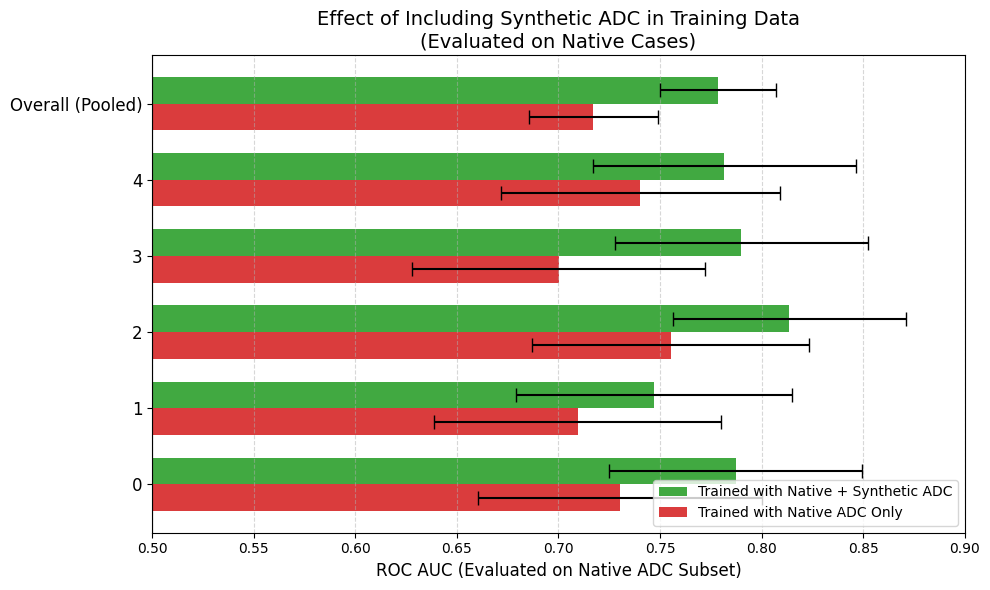

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
df_paired = pd.read_csv('Files/Statistical_Test/paired_per_fold_der_vs_noder_native.csv')
df_overall = pd.read_csv('Files/Statistical_Test/paired_overall_der_vs_noder_native.csv')

# Preparar datos
folds = df_paired['fold'].tolist() + ["Overall (Pooled)"]
# DER = Entrenado con Sintéticas + Nativas
der_auc = df_paired['DER_nat_auc'].tolist() + [df_overall['DER_nat_auc'][0]]
# NODER = Entrenado solo con Nativas
noder_auc = df_paired['NODER_auc'].tolist() + [df_overall['NODER_auc'][0]]

# Errores
der_err = [
    df_paired['DER_nat_auc'] - df_paired['DER_nat_lo'], 
    df_paired['DER_nat_hi'] - df_paired['DER_nat_auc']
]
der_err[0] = pd.concat([der_err[0], pd.Series([df_overall['DER_nat_auc'][0] - df_overall['DER_nat_lo'][0]])]).tolist()
der_err[1] = pd.concat([der_err[1], pd.Series([df_overall['DER_nat_hi'][0] - df_overall['DER_nat_auc'][0]])]).tolist()

noder_err = [
    df_paired['NODER_auc'] - df_paired['NODER_lo'], 
    df_paired['NODER_hi'] - df_paired['NODER_auc']
]
noder_err[0] = pd.concat([noder_err[0], pd.Series([df_overall['NODER_auc'][0] - df_overall['NODER_lo'][0]])]).tolist()
noder_err[1] = pd.concat([noder_err[1], pd.Series([df_overall['NODER_hi'][0] - df_overall['NODER_auc'][0]])]).tolist()

# Plot
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(folds))
height = 0.35

# Etiquetas corregidas
plt.barh(y_pos + height/2, der_auc, height, xerr=der_err, label='Trained with Native + Synthetic ADC', capsize=5, color='#2ca02c', alpha=0.9)
plt.barh(y_pos - height/2, noder_auc, height, xerr=noder_err, label='Trained with Native ADC Only', capsize=5, color='#d62728', alpha=0.9)

plt.yticks(y_pos, folds, fontsize=12)
plt.xlabel('ROC AUC (Evaluated on Native ADC Subset)', fontsize=12)
plt.title('Effect of Including Synthetic ADC in Training Data\n(Evaluated on Native Cases)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0.5, 0.90)
plt.axvline(x=0.5, color='k', linestyle='-')

plt.tight_layout()
plt.show()

# Department Analysis

In [3]:
import json, numpy as np, pandas as pd, os
from typing import List
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

# ---------- set your inputs ----------
CSV_PATH = "Files/data_with_splits_dep_disjoint.csv"  # change if needed

der_paths = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/results.json',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/results.json',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/results.json',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json',
]

PALETTE = ["#efc86e","#6f9969","#97c684","#aab5d5","#808fe1","#5c66a8","#454a74"]
OUTDIR = "Files/Statistical_Test/Department"
os.makedirs(OUTDIR, exist_ok=True)

# ---------- DeLong (positives first) ----------
# --------- DeLong (positives first) ---------
def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N, float); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1)+1; i = j
    out = np.empty(N, float); out[J] = T; return out

def _fast_delong_core(preds_sorted_T, label_1_count):
    k, n = preds_sorted_T.shape
    m = int(label_1_count); n_neg = n - m
    pos = preds_sorted_T[:, :m]; neg = preds_sorted_T[:, m:]
    tx = np.zeros((k, m), float); ty = np.zeros((k, n_neg), float); tz = np.zeros((k, n), float)
    for r in range(k):
        tx[r] = _compute_midrank(pos[r]); ty[r] = _compute_midrank(neg[r]); tz[r] = _compute_midrank(preds_sorted_T[r])
    aucs = (tz[:, :m].mean(axis=1) - (m + 1)/2.0) / float(n_neg)
    v01 = (tz[:, :m] - tx) / n_neg; v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01)); sy = np.atleast_2d(np.cov(v10)); S = sx / m + sy / n_neg
    return aucs, S

def delong_roc_variance(y_true, y_scores):
    y_true = np.asarray(y_true, int); y_scores = np.asarray(y_scores, float)
    if np.unique(y_true).size < 2: raise ValueError("ROC indefinido: una sola clase.")
    order = np.argsort(-y_true)  # positivos primero
    y_sorted = y_true[order]; s_sorted = y_scores[order]; m = int(y_sorted.sum())
    aucs, S = _fast_delong_core(np.expand_dims(s_sorted, 0), m)
    auc_point = float(roc_auc_score(y_true, y_scores)); var = float(np.atleast_2d(S)[0,0])
    return auc_point, var

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    from scipy.stats import norm
    auc, var = delong_roc_variance(y_true, y_scores); z = norm.ppf(0.5 + alpha/2.0)
    se = np.sqrt(max(var, 1e-12)); lo = max(0.0, auc - z*se); hi = min(1.0, auc + z*se)
    return auc, lo, hi, var

def delong_roc_test_indep(y1, s1, y2, s2):
    from scipy.stats import norm
    a1, v1 = delong_roc_variance(y1, s1); a2, v2 = delong_roc_variance(y2, s2)
    z = (a1 - a2) / np.sqrt(max(v1,1e-12)+max(v2,1e-12))
    p = 2*(1 - norm.cdf(abs(z))); return a1-a2, p, v1, v2

def pr_auc_ci(y, p, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed); y = np.asarray(y, int); p = np.asarray(p, float)
    ap = average_precision_score(y, p); idx = np.arange(len(y)); boots = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        if np.unique(y[b]).size < 2: continue
        boots.append(average_precision_score(y[b], p[b]))
    if len(boots)==0: return ap, np.nan, np.nan
    lo, hi = np.percentile(boots,[2.5,97.5]); return ap, float(lo), float(hi)

def calibration_slope_intercept(y, p):
    import statsmodels.api as sm
    eps = 1e-6
    p = np.clip(np.asarray(p,float), eps, 1-eps)
    x = np.log(p/(1-p))
    X = sm.add_constant(x)
    model = sm.Logit(np.asarray(y,int), X).fit(disp=False)
    b0, b1 = model.params
    return float(b0), float(b1)

def threshold_from_overall(y, p):
    fpr, tpr, thr = roc_curve(y, p); J = tpr - fpr; return float(thr[np.argmax(J)])

# --------- load validation table ---------
df = pd.read_csv(CSV_PATH, sep=None, engine="python")
df["key"] = df["subject"].astype(str) + "||" + df["session"].astype(str)
val = df[df["split"]=="val"].copy().reset_index(drop=True)
val["label"] = val["csPC"].astype(int)

# --------- read DER folds and average probabilities ---------
def load_fold_predictions(paths: List[str], default_ids_df: pd.DataFrame):
    folds = []
    for p in paths:
        with open(p, "r") as f: d = json.load(f)
        probs_pos = np.array(d['Validation Predictions'])
        probs_pos = probs_pos[:,1] if probs_pos.ndim==2 else probs_pos
        if 'Validation Subjects' in d and 'Validation Sessions' in d:
            ids = pd.DataFrame({"subject": d['Validation Subjects'], "session": d['Validation Sessions']})
            ids["key"] = ids["subject"].astype(str)+"||"+ids["session"].astype(str)
        else:
            # fallback: orden de val
            ids = default_ids_df[["subject","session","key"]].reset_index(drop=True).copy()
            n = min(len(ids), len(probs_pos))
            ids = ids.iloc[:n].reset_index(drop=True)
            probs_pos = probs_pos[:n]
        folds.append({"probs": probs_pos.astype(float), "ids": ids})
    return folds

def average_across_folds(folds, ref_df):
    key_to_idx = {k:i for i,k in enumerate(ref_df["key"].tolist())}
    n = len(ref_df); sums = np.zeros(n, float); counts = np.zeros(n, int)
    for fold in folds:
        keys = fold["ids"]["key"].tolist()
        probs = fold["probs"]
        m = min(len(keys), len(probs))
        for i in range(m):
            k = keys[i]
            idx = key_to_idx.get(k, None)
            if idx is None: continue
            sums[idx] += probs[i]; counts[idx] += 1
    mean = np.divide(sums, counts, out=np.full(n, np.nan), where=counts>0)
    return mean, counts

In [9]:
folds_der = load_fold_predictions(der_paths, default_ids_df=val)
p_der_mean, counts = average_across_folds(folds_der, ref_df=val)

val["score"] = p_der_mean
val = val.dropna(subset=["score"]).reset_index(drop=True)

work = val[["dep","label","score"]].dropna().copy()
work["dep"] = work["dep"].astype(str)

# --------- metrics by dep ---------
rows = []
for g, d in work.groupby("dep"):
    y = d["label"].to_numpy(); p = d["score"].to_numpy()
    n, npos = len(y), int(y.sum()); prev = npos/max(n,1)
    brier = float(np.mean((y-p)**2))
    if np.unique(y).size < 2:
        rows.append({"dep":g,"n":n,"n_pos":npos,"prev":prev,
                     "roc_auc":np.nan,"roc_lo":np.nan,"roc_hi":np.nan,
                     "pr_auc":np.nan,"pr_lo":np.nan,"pr_hi":np.nan,
                     "brier":brier,"cal_intercept":np.nan,"cal_slope":np.nan})
        continue
    auc, lo, hi, _ = auc_ci_delong(y, p); ap, apl, aph = pr_auc_ci(y, p)
    try:
        b0, b1 = calibration_slope_intercept(y, p)
    except Exception:
        b0, b1 = np.nan, np.nan
    rows.append({"dep":g,"n":n,"n_pos":npos,"prev":prev,
                 "roc_auc":auc,"roc_lo":lo,"roc_hi":hi,
                 "pr_auc":ap,"pr_lo":apl,"pr_hi":aph,
                 "brier":brier,"cal_intercept":b0,"cal_slope":b1})

dep_metrics = pd.DataFrame(rows).sort_values("dep").reset_index(drop=True)
display(dep_metrics)

# --------- pairwise AUC tests + FDR ---------
pairs = []
levels = dep_metrics["dep"].tolist()
for i in range(len(levels)):
    for j in range(i+1, len(levels)):
        g1, g2 = levels[i], levels[j]
        d1 = work[work["dep"]==g1]; d2 = work[work["dep"]==g2]
        y1, p1 = d1["label"].to_numpy(), d1["score"].to_numpy()
        y2, p2 = d2["label"].to_numpy(), d2["score"].to_numpy()
        if np.unique(y1).size<2 or np.unique(y2).size<2:
            diff, pval, n1, n2 = np.nan, np.nan, len(y1), len(y2)
        else:
            diff, pval, _, _ = delong_roc_test_indep(y1,p1,y2,p2)
            n1, n2 = len(y1), len(y2)
        pairs.append({"g1":g1,"g2":g2,"delta_auc":diff,"p_value":pval,"n1":n1,"n2":n2})
pairwise = pd.DataFrame(pairs).sort_values("p_value", na_position="last").reset_index(drop=True)
m = pairwise["p_value"].notna().sum()
ranks = np.arange(1, len(pairwise)+1)
pairwise["p_fdr"] = (pairwise["p_value"] * (m / ranks)).clip(upper=1.0)
display(pairwise)

# --------- global interaction test ---------
try:
    import statsmodels.formula.api as smf
    dfm = work[["dep","label","score"]].copy()
    full = smf.logit("label ~ score + C(dep) + score:C(dep)", data=dfm).fit(disp=False)
    red  = smf.logit("label ~ score + C(dep)", data=dfm).fit(disp=False)
    from scipy.stats import chi2
    LR = 2*(full.llf - red.llf); df_chi = full.df_model - red.df_model
    p_int = 1-chi2.cdf(LR, df_chi)
    print({"LR": float(LR), "df": int(df_chi), "p_interaction": float(p_int),
           "k_levels": int(dfm["dep"].nunique()), "n": int(len(dfm))})
except Exception as e:
    print("Global interaction test failed:", e)

# --------- threshold-based fairness ---------
thr = threshold_from_overall(work["label"].to_numpy(), work["score"].to_numpy())

def conf_metrics(y, p, t):
    y = np.asarray(y,int); pred = (np.asarray(p,float) >= t).astype(int)
    tp = int(((pred==1)&(y==1)).sum()); tn = int(((pred==0)&(y==0)).sum())
    fp = int(((pred==1)&(y==0)).sum()); fn = int(((pred==0)&(y==1)).sum())
    TPR = tp/max(tp+fn,1); FPR = fp/max(fp+tn,1); PPV = tp/max(tp+fp,1); NPV = tn/max(tn+fn,1)
    return TPR,FPR,PPV,NPV

rows_thr = []
TPR0,FPR0,PPV0,NPV0 = conf_metrics(work["label"], work["score"], thr)
rows_thr.append({"dep":"ALL","n":len(work),"prev":work["label"].mean(),
                 "TPR":TPR0,"FPR":FPR0,"PPV":PPV0,"NPV":NPV0})
for g, d in work.groupby("dep"):
    tpr,fpr,ppv,npv = conf_metrics(d["label"], d["score"], thr)
    rows_thr.append({"dep":g,"n":len(d),"prev":d["label"].mean(),
                     "TPR":tpr,"FPR":fpr,"PPV":ppv,"NPV":npv,
                     "TPR_gap": tpr-TPR0, "FPR_gap": fpr-FPR0,
                     "PPV_gap": ppv-PPV0, "NPV_gap": npv-NPV0})
thr_tbl = pd.DataFrame(rows_thr)
display(thr_tbl)

# --------- Professional plots ---------
# AUC bars + CI
x = dep_metrics["dep"].astype(str).tolist()
y = dep_metrics["roc_auc"].tolist()
lo = dep_metrics["roc_lo"].tolist()
hi = dep_metrics["roc_hi"].tolist()
err_y = dict(
    type='data', symmetric=False,
    array=[(hi_i - y_i) if pd.notna(hi_i) and pd.notna(y_i) else 0 for hi_i,y_i in zip(hi,y)],
    arrayminus=[(y_i - lo_i) if pd.notna(lo_i) and pd.notna(y_i) else 0 for lo_i,y_i in zip(lo,y)],
    thickness=2, width=8
)
auc_fig = go.Figure()
auc_fig.add_trace(go.Bar(
    x=x, y=y, error_y=err_y,
    marker=dict(color=[PALETTE[i % len(PALETTE)] for i in range(len(x))],
                line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    name="ROC-AUC", width=0.6
))
auc_fig.update_layout(
    title=dict(text="<b>ROC-AUC by Department</b><br><sub>95% Confidence Intervals (DeLong)</sub>",
               x=0.5, xanchor='center', font=dict(size=18)),
    xaxis=dict(title="<b>Department</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(title="<b>ROC-AUC</b>", tickfont=dict(size=12), title_font=dict(size=14),
               gridcolor='rgba(200,200,200,0.3)', range=[0, 1]),
    plot_bgcolor='white', paper_bgcolor='white',
    showlegend=False, height=500, margin=dict(t=100, b=80, l=80, r=40)
)
auc_fig.show()

# Prevalence bars
prev_fig = go.Figure()
prev_fig.add_trace(go.Bar(
    x=dep_metrics["dep"].astype(str), y=dep_metrics["prev"],
    marker=dict(color=[PALETTE[i % len(PALETTE)] for i in range(len(dep_metrics))],
                line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    text=[f"{v:.1%}" for v in dep_metrics["prev"]], textposition='outside',
    textfont=dict(size=11), width=0.6
))
prev_fig.update_layout(
    title=dict(text="<b>csPC Prevalence by Department</b>",
               x=0.5, xanchor='center', font=dict(size=18)),
    xaxis=dict(title="<b>Department</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(title="<b>Prevalence</b>", tickfont=dict(size=12), title_font=dict(size=14),
               tickformat='.0%', gridcolor='rgba(200,200,200,0.3)', range=[0, max(dep_metrics["prev"])*1.15]),
    plot_bgcolor='white', paper_bgcolor='white',
    showlegend=False, height=500, margin=dict(t=80, b=80, l=80, r=40)
)
prev_fig.show()

sub = thr_tbl[thr_tbl["dep"]!="ALL"].copy()
fair_fig = go.Figure()

# Usar colores fijos para TPR y FPR
fair_fig.add_trace(go.Bar(
    x=sub["dep"].astype(str), y=sub["TPR_gap"], name="TPR gap",
    marker=dict(color=PALETTE[0], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    width=0.35
))
fair_fig.add_trace(go.Bar(
    x=sub["dep"].astype(str), y=sub["FPR_gap"], name="FPR gap",
    marker=dict(color=PALETTE[1], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    width=0.35
))
fair_fig.update_layout(
    barmode='group',
    title=dict(text=f"<b>Fairness Gaps</b><br><sub>Common threshold: {thr:.3f}</sub>",
               x=0.5, xanchor='center', font=dict(size=18)),
    xaxis=dict(title="<b>Department</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(title="<b>Difference vs. overall</b>", tickfont=dict(size=12), title_font=dict(size=14),
               gridcolor='rgba(200,200,200,0.3)', zeroline=True, zerolinecolor='rgba(0,0,0,0.5)', zerolinewidth=2),
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(x=0.98, y=0.98, xanchor='right', yanchor='top', bgcolor='rgba(255,255,255,0.8)',
                bordercolor='rgba(0,0,0,0.2)', borderwidth=1, font=dict(size=12)),
    height=500, margin=dict(t=100, b=80, l=80, r=40)
)
fair_fig.show()


,dep,n,n_pos,prev,roc_auc,roc_lo,roc_hi,pr_auc,pr_lo,pr_hi,brier,cal_intercept,cal_slope
0,17.0,48,29,0.604167,0.527223,0.354346,0.700101,0.622705,0.464850,0.827650,0.321061,0.418778,0.058910
1,5.0,41,15,0.365854,0.433333,0.246430,0.620237,0.360254,0.214768,0.590041,0.365195,-0.575607,-0.093773
2,7.0,54,26,0.481481,0.424451,0.266762,0.582139,0.515275,0.335071,0.688887,0.377430,-0.142286,-0.186975


,g1,g2,delta_auc,p_value,n1,n2,p_fdr
0,17.0,7.0,0.102773,0.389324,48,54,1.000000
1,17.0,5.0,0.093890,0.469807,48,41,0.704710
2,5.0,7.0,0.008883,0.943242,41,54,0.943242


{'LR': 0.9094576205374665, 'df': 2, 'p_interaction': 0.6346200470541474, 'k_levels': 3, 'n': 143}


,dep,n,prev,TPR,FPR,PPV,NPV,TPR_gap,FPR_gap,PPV_gap,NPV_gap
0,ALL,143,0.489510,0.085714,0.027397,0.750000,0.525926,NaN,NaN,NaN,NaN
1,17.0,48,0.604167,0.068966,0.052632,0.666667,0.400000,-0.016749,0.025234,-0.083333,-0.125926
2,5.0,41,0.365854,0.066667,0.038462,0.500000,0.641026,-0.019048,0.011064,-0.250000,0.115100
3,7.0,54,0.481481,0.115385,0.000000,1.000000,0.549020,0.029670,-0.027397,0.250000,0.023094


In [1]:
# Analysis with CSV

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from scipy.stats import norm, chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.graph_objects as go

# =========================
# CONFIGURACIÓN
# =========================
CSV_PROBS = "Files/data_with_splits_dep_disjoint_train_val_probs.csv"  # ajusta ruta si hace falta
SPLIT_TO_USE = "train"          # "train", "val" o "test", lo que quieras analizar
SCORE_COL = "prob_fold_0"        # o "prob_fold_0", etc.

PALETTE = [
    "#efc86e",
    "#6f9969",
    "#97c684",
    "#aab5d5",
    "#808fe1",
    "#5c66a8",
    "#454a74",
]

# =========================
# DeLong y utilidades
# =========================

def _compute_midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(N, dtype=float)
    out[J] = T
    return out

def fastDeLong(predictions_sorted_transposed, label_1_count):
    """
    Implementación estándar de DeLong para AUC y matriz de covarianza.
    predictions_sorted_transposed: shape (n_classifiers, n_examples)
    label_1_count: número de positivos.
    """
    m = int(label_1_count)
    n = predictions_sorted_transposed.shape[1] - m

    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m), dtype=float)
    ty = np.empty((k, n), dtype=float)
    tz = np.empty((k, m + n), dtype=float)

    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])

    # AUC de DeLong
    aucs = (tz[:, :m].sum(axis=1) / m - (m + 1) / 2.0) / n

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)
    
    # Ensure sx and sy are 2D
    sx = np.atleast_2d(sx)
    sy = np.atleast_2d(sy)
    
    s = sx / m + sy / n
    return aucs, s

def delong_roc_variance(y_true, y_scores):
    y_true = np.asarray(y_true, int)
    y_scores = np.asarray(y_scores, float)

    if np.unique(y_true).size < 2:
        return np.nan, np.nan

    # Ordenar por score descendente
    order = np.argsort(-y_scores)
    y_sorted = y_true[order]
    s_sorted = y_scores[order]

    m = int(y_sorted.sum())
    if m == 0 or m == len(y_sorted):
        return np.nan, np.nan

    preds_sorted_T = s_sorted.reshape(1, -1)
    aucs, cov = fastDeLong(preds_sorted_T, m)
    
    # Handle both scalar and array returns
    auc_val = float(aucs[0]) if hasattr(aucs, '__getitem__') else float(aucs)
    cov_val = float(cov[0, 0]) if cov.ndim == 2 else float(cov)
    
    return auc_val, cov_val

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    auc, var = delong_roc_variance(y_true, y_scores)
    if not np.isfinite(auc) or not np.isfinite(var) or var <= 0:
        return np.nan, np.nan, np.nan, np.nan
    z = norm.ppf(0.5 + alpha / 2.0)
    se = np.sqrt(var)
    lo = max(0.0, auc - z * se)
    hi = min(1.0, auc + z * se)
    return float(auc), float(lo), float(hi), float(var)

def delong_roc_test_indep(y1, s1, y2, s2):
    """
    Test de diferencia de AUC para dos grupos INDEPENDIENTES (DeLong independiente).
    """
    auc1, var1 = delong_roc_variance(y1, s1)
    auc2, var2 = delong_roc_variance(y2, s2)
    if not (np.isfinite(var1) and np.isfinite(var2) and var1 > 0 and var2 > 0):
        return np.nan, np.nan, var1, var2
    diff = auc1 - auc2
    se = np.sqrt(var1 + var2)
    z = diff / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(diff), float(p), float(var1), float(var2)

def pr_auc_ci(y_true, y_scores, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, int)
    y_scores = np.asarray(y_scores, float)

    if np.unique(y_true).size < 2:
        return np.nan, np.nan, np.nan

    ap = average_precision_score(y_true, y_scores)
    idx = np.arange(len(y_true))
    boots = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        if np.unique(y_true[b]).size < 2:
            continue
        boots.append(average_precision_score(y_true[b], y_scores[b]))
    if len(boots) == 0:
        return float(ap), np.nan, np.nan
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(ap), float(lo), float(hi)

def calibration_slope_intercept(y, p):
    """
    Regresión logística: y ~ logit(p), devolviendo intercepto y pendiente.
    """
    eps = 1e-6
    p = np.clip(np.asarray(p, float), eps, 1 - eps)
    y = np.asarray(y, int)
    x = np.log(p / (1 - p))
    X = sm.add_constant(x)
    model = sm.Logit(y, X).fit(disp=False)
    b0, b1 = model.params
    return float(b0), float(b1)

def threshold_from_overall(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    J = tpr - fpr
    return float(thr[np.argmax(J)])

def conf_metrics(y, p, t):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    pred = (p >= t).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum())
    tn = int(((pred == 0) & (y == 0)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum())
    TPR = tp / max(tp + fn, 1)
    FPR = fp / max(fp + tn, 1)
    PPV = tp / max(tp + fp, 1)
    NPV = tn / max(tn + fn, 1)
    return TPR, FPR, PPV, NPV

# =========================
# Cargar CSV y preparar datos
# =========================

df = pd.read_csv(CSV_PROBS, sep=None, engine="python")

# Etiqueta
df["label"] = df["csPC"].astype(int)

# Filtrar split
work = df[df["split"] == SPLIT_TO_USE].copy()
if SCORE_COL not in work.columns:
    raise RuntimeError(f"La columna '{SCORE_COL}' no existe en el CSV.")

work = work[["dep", "label", SCORE_COL]].rename(columns={SCORE_COL: "score"})
work = work.dropna(subset=["dep", "label", "score"]).copy()
work["dep"] = work["dep"].astype(str)

print(f"Filas en split={SPLIT_TO_USE}: {len(work)}")
print("Departamentos:", sorted(work["dep"].unique()))

# =========================
# Métricas por departamento
# =========================

rows = []
for g, d in work.groupby("dep"):
    y = d["label"].to_numpy()
    p = d["score"].to_numpy()
    n = len(y)
    n_pos = int(y.sum())
    prev = n_pos / max(n, 1)
    brier = float(np.mean((y - p) ** 2))

    if np.unique(y).size < 2:
        rows.append({
            "dep": g, "n": n, "n_pos": n_pos, "prev": prev,
            "roc_auc": np.nan, "roc_lo": np.nan, "roc_hi": np.nan,
            "pr_auc": np.nan, "pr_lo": np.nan, "pr_hi": np.nan,
            "brier": brier, "cal_intercept": np.nan, "cal_slope": np.nan
        })
        continue

    auc, lo, hi, _ = auc_ci_delong(y, p)
    ap, apl, aph = pr_auc_ci(y, p)
    try:
        b0, b1 = calibration_slope_intercept(y, p)
    except Exception:
        b0, b1 = np.nan, np.nan

    rows.append({
        "dep": g,
        "n": n,
        "n_pos": n_pos,
        "prev": prev,
        "roc_auc": auc,
        "roc_lo": lo,
        "roc_hi": hi,
        "pr_auc": ap,
        "pr_lo": apl,
        "pr_hi": aph,
        "brier": brier,
        "cal_intercept": b0,
        "cal_slope": b1
    })

dep_metrics = pd.DataFrame(rows).sort_values("dep").reset_index(drop=True)
display(dep_metrics)

# =========================
# Pairwise AUC tests + FDR
# =========================

pairs = []
levels = dep_metrics["dep"].tolist()
for i in range(len(levels)):
    for j in range(i + 1, len(levels)):
        g1, g2 = levels[i], levels[j]
        d1 = work[work["dep"] == g1]
        d2 = work[work["dep"] == g2]
        y1, p1 = d1["label"].to_numpy(), d1["score"].to_numpy()
        y2, p2 = d2["label"].to_numpy(), d2["score"].to_numpy()
        if np.unique(y1).size < 2 or np.unique(y2).size < 2:
            diff, pval, n1, n2 = np.nan, np.nan, len(y1), len(y2)
        else:
            diff, pval, _, _ = delong_roc_test_indep(y1, p1, y2, p2)
            n1, n2 = len(y1), len(y2)
        pairs.append({
            "g1": g1, "g2": g2,
            "delta_auc": diff,
            "p_value": pval,
            "n1": n1, "n2": n2
        })

pairwise = pd.DataFrame(pairs).sort_values("p_value", na_position="last").reset_index(drop=True)
m = pairwise["p_value"].notna().sum()
ranks = np.arange(1, len(pairwise) + 1)
pairwise["p_fdr"] = (pairwise["p_value"] * (m / ranks)).clip(upper=1.0)
display(pairwise)

# =========================
# Global interaction test score × dep
# =========================

try:
    dfm = work[["dep", "label", "score"]].copy()
    full = smf.logit("label ~ score + C(dep) + score:C(dep)", data=dfm).fit(disp=False)
    red  = smf.logit("label ~ score + C(dep)", data=dfm).fit(disp=False)
    LR = 2 * (full.llf - red.llf)
    df_chi = full.df_model - red.df_model
    p_int = 1 - chi2.cdf(LR, df_chi)
    print({
        "LR": float(LR),
        "df": int(df_chi),
        "p_interaction": float(p_int),
        "k_levels": int(dfm["dep"].nunique()),
        "n": int(len(dfm))
    })
except Exception as e:
    print("Global interaction test failed:", e)

# =========================
# Threshold-based fairness
# =========================

thr = threshold_from_overall(work["label"].to_numpy(), work["score"].to_numpy())
print(f"Umbral global (Youden) en split={SPLIT_TO_USE}: {thr:.4f}")

rows_thr = []
TPR0, FPR0, PPV0, NPV0 = conf_metrics(work["label"], work["score"], thr)
rows_thr.append({
    "dep": "ALL",
    "n": len(work),
    "prev": work["label"].mean(),
    "TPR": TPR0,
    "FPR": FPR0,
    "PPV": PPV0,
    "NPV": NPV0
})
for g, d in work.groupby("dep"):
    tpr, fpr, ppv, npv = conf_metrics(d["label"], d["score"], thr)
    rows_thr.append({
        "dep": g,
        "n": len(d),
        "prev": d["label"].mean(),
        "TPR": tpr,
        "FPR": fpr,
        "PPV": ppv,
        "NPV": npv,
        "TPR_gap": tpr - TPR0,
        "FPR_gap": fpr - FPR0,
        "PPV_gap": ppv - PPV0,
        "NPV_gap": npv - NPV0
    })

thr_tbl = pd.DataFrame(rows_thr)
display(thr_tbl)

# =========================
# Plots "bonitos" para suplemento
# =========================

# AUC por dep + CI
x = dep_metrics["dep"].astype(str).tolist()
y = dep_metrics["roc_auc"].tolist()
lo = dep_metrics["roc_lo"].tolist()
hi = dep_metrics["roc_hi"].tolist()
err_y = dict(
    type='data', symmetric=False,
    array=[(hi_i - y_i) if pd.notna(hi_i) and pd.notna(y_i) else 0.0 for hi_i, y_i in zip(hi, y)],
    arrayminus=[(y_i - lo_i) if pd.notna(lo_i) and pd.notna(y_i) else 0.0 for lo_i, y_i in zip(lo, y)],
    thickness=2, width=8
)

auc_fig = go.Figure()
auc_fig.add_trace(go.Bar(
    x=x, y=y, error_y=err_y,
    marker=dict(
        color=[PALETTE[i % len(PALETTE)] for i in range(len(x))],
        line=dict(color='rgba(0,0,0,0.3)', width=1.5)
    ),
    name="ROC-AUC", width=0.6
))
auc_fig.update_layout(
    title=dict(
        text=f"<b>ROC-AUC by Department ({SPLIT_TO_USE})</b><br><sub>95% CI (DeLong)</sub>",
        x=0.5, xanchor='center', font=dict(size=18)
    ),
    xaxis=dict(title="<b>Department</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>ROC-AUC</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)',
        range=[0, 1]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=500,
    margin=dict(t=100, b=80, l=80, r=40)
)
auc_fig.show()

# Prevalencia por dep
prev_fig = go.Figure()
prev_fig.add_trace(go.Bar(
    x=dep_metrics["dep"].astype(str), y=dep_metrics["prev"],
    marker=dict(
        color=[PALETTE[i % len(PALETTE)] for i in range(len(dep_metrics))],
        line=dict(color='rgba(0,0,0,0.3)', width=1.5)
    ),
    text=[f"{v:.1%}" for v in dep_metrics["prev"]],
    textposition='outside',
    textfont=dict(size=11),
    width=0.6
))
prev_fig.update_layout(
    title=dict(
        text=f"<b>csPC Prevalence by Department ({SPLIT_TO_USE})</b>",
        x=0.5, xanchor='center', font=dict(size=18)
    ),
    xaxis=dict(title="<b>Department</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>Prevalence</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        tickformat='.0%',
        gridcolor='rgba(200,200,200,0.3)',
        range=[0, max(dep_metrics["prev"])*1.15]
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    height=500,
    margin=dict(t=80, b=80, l=80, r=40)
)
prev_fig.show()

# Fairness: TPR/FPR gaps
sub = thr_tbl[thr_tbl["dep"] != "ALL"].copy()
fair_fig = go.Figure()
fair_fig.add_trace(go.Bar(
    x=sub["dep"].astype(str), y=sub["TPR_gap"],
    name="TPR gap",
    marker=dict(color=PALETTE[0], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    width=0.35
))
fair_fig.add_trace(go.Bar(
    x=sub["dep"].astype(str), y=sub["FPR_gap"],
    name="FPR gap",
    marker=dict(color=PALETTE[1], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    width=0.35
))
fair_fig.update_layout(
    barmode='group',
    title=dict(
        text=f"<b>Fairness Gaps by Department ({SPLIT_TO_USE})</b><br><sub>Common threshold: {thr:.3f}</sub>",
        x=0.5, xanchor='center', font=dict(size=18)
    ),
    xaxis=dict(title="<b>Department</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>Difference vs overall</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor='rgba(200,200,200,0.3)',
        zeroline=True,
        zerolinecolor='rgba(0,0,0,0.5)',
        zerolinewidth=2
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        x=0.98, y=0.98, xanchor='right', yanchor='top',
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='rgba(0,0,0,0.2)',
        borderwidth=1,
        font=dict(size=12)
    ),
    height=500,
    margin=dict(t=100, b=80, l=80, r=40)
)
fair_fig.show()


Filas en split=train: 3675
Departamentos: ['17.0', '5.0', '7.0']


,dep,n,n_pos,prev,roc_auc,roc_lo,roc_hi,pr_auc,pr_lo,pr_hi,brier,cal_intercept,cal_slope
0,17.0,1782,1194,0.670034,NaN,NaN,NaN,0.947491,0.932703,0.960432,0.105616,0.518471,1.206944
1,5.0,801,258,0.322097,NaN,NaN,NaN,0.719175,0.662637,0.778678,0.147546,-0.233045,0.897113
2,7.0,1092,578,0.529304,NaN,NaN,NaN,0.888061,0.861913,0.911962,0.135170,-0.039478,1.147170


,g1,g2,delta_auc,p_value,n1,n2,p_fdr
0,17.0,5.0,NaN,NaN,1782,801,NaN
1,17.0,7.0,NaN,NaN,1782,1092,NaN
2,5.0,7.0,NaN,NaN,801,1092,NaN


{'LR': 13.088208915707128, 'df': 2, 'p_interaction': 0.001438571807568012, 'k_levels': 3, 'n': 3675}
Umbral global (Youden) en split=train: 0.4862


,dep,n,prev,TPR,FPR,PPV,NPV,TPR_gap,FPR_gap,PPV_gap,NPV_gap
0,ALL,3675,0.552381,0.833990,0.158055,0.866871,0.804297,NaN,NaN,NaN,NaN
1,17.0,1782,0.670034,0.881072,0.168367,0.913988,0.774960,0.047082,0.010313,0.047116,-0.029337
2,5.0,801,0.322097,0.608527,0.119705,0.707207,0.825561,-0.225463,-0.038349,-0.159664,0.021264
3,7.0,1092,0.529304,0.837370,0.186770,0.834483,0.816406,0.003380,0.028716,-0.032389,0.012109


In [2]:
df = pd.read_csv(CSV_PROBS, sep=None, engine="python")

In [3]:
df.dep.value_counts()

dep
17.0    1973
7.0     1216
5.0      890
Name: count, dtype: int64

# Age analysis

In [12]:
# Add output directory configuration at the top (after imports)
OUTPUT_DIR = "Files/Statistical_Test/Age" 
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

import json, numpy as np, pandas as pd
from typing import List, Optional
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import chi2

# --------- inputs ---------
CSV_PATH = "Files/data_with_splits_dep_disjoint.csv"  # ajusta si procede
der_paths = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/results.json',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/results.json',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/results.json',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json',
]
PALETTE = ["#efc86e","#6f9969","#97c684","#aab5d5","#808fe1","#5c66a8","#454a74"]

# Binning config (usa cuantiles por defecto; puedes definir bins custom)
N_QUANTILES = 4
CUSTOM_BINS: Optional[list] = None   # e.g., [40,60,70,80,95]
CUSTOM_LABELS: Optional[list] = None

# --------- DeLong, calibración, umbral ---------
def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N, float); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1)+1; i = j
    out = np.empty(N, float); out[J] = T; return out

def _fast_delong_core(preds_sorted_T, label_1_count):
    k, n = preds_sorted_T.shape
    m = int(label_1_count); n_neg = n - m
    pos = preds_sorted_T[:, :m]; neg = preds_sorted_T[:, m:]
    tx = np.zeros((k, m), float); ty = np.zeros((k, n_neg), float); tz = np.zeros((k, n), float)
    for r in range(k):
        tx[r] = _compute_midrank(pos[r]); ty[r] = _compute_midrank(neg[r]); tz[r] = _compute_midrank(preds_sorted_T[r])
    aucs = (tz[:, :m].mean(axis=1) - (m + 1)/2.0) / float(n_neg)
    v01 = (tz[:, :m] - tx) / n_neg; v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01)); sy = np.atleast_2d(np.cov(v10)); S = sx / m + sy / n_neg
    return aucs, S

def delong_roc_variance(y_true, y_scores):
    y_true = np.asarray(y_true, int); y_scores = np.asarray(y_scores, float)
    if np.unique(y_true).size < 2: raise ValueError("ROC indefinida: grupo con una sola clase.")
    order = np.argsort(-y_true)  # positivos primero
    y_sorted = y_true[order]; s_sorted = y_scores[order]; m = int(y_sorted.sum())
    aucs, S = _fast_delong_core(np.expand_dims(s_sorted, 0), m)
    auc_point = float(roc_auc_score(y_true, y_scores)); var = float(np.atleast_2d(S)[0,0])
    return auc_point, var

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    from scipy.stats import norm
    auc, var = delong_roc_variance(y_true, y_scores); z = norm.ppf(0.5 + alpha/2.0)
    se = np.sqrt(max(var, 1e-12)); lo = max(0.0, auc - z*se); hi = min(1.0, auc + z*se)
    return auc, lo, hi, var

def delong_roc_test_indep(y1, s1, y2, s2):
    from scipy.stats import norm
    a1, v1 = delong_roc_variance(y1, s1); a2, v2 = delong_roc_variance(y2, s2)
    z = (a1 - a2) / np.sqrt(max(v1,1e-12)+max(v2,1e-12))
    p = 2*(1 - norm.cdf(abs(z))); return a1-a2, p, v1, v2

def pr_auc_ci(y, p, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed); y = np.asarray(y, int); p = np.asarray(p, float)
    ap = average_precision_score(y, p); idx = np.arange(len(y)); boots = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        if np.unique(y[b]).size < 2: continue
        boots.append(average_precision_score(y[b], p[b]))
    if len(boots)==0: return ap, np.nan, np.nan
    lo, hi = np.percentile(boots,[2.5,97.5]); return ap, float(lo), float(hi)

def calibration_slope_intercept(y, p):
    import statsmodels.api as sm
    eps = 1e-6
    p = np.clip(np.asarray(p,float), eps, 1-eps)
    x = np.log(p/(1-p))
    X = sm.add_constant(x)
    model = sm.Logit(np.asarray(y,int), X).fit(disp=False)
    b0, b1 = model.params
    return float(b0), float(b1)

def threshold_from_overall(y, p):
    fpr, tpr, thr = roc_curve(y, p); J = tpr - fpr; return float(thr[np.argmax(J)])

# --------- carga validación ---------
df = pd.read_csv(CSV_PATH, sep=None, engine="python")
assert "ED" in df.columns, "No se encontró la columna 'ED' (edad)."
df["key"] = df["subject"].astype(str) + "||" + df["session"].astype(str)
val = df[df["split"]=="val"].copy().reset_index(drop=True)
val["label"] = val["csPC"].astype(int)
val["ED"] = pd.to_numeric(val["ED"], errors="coerce")

# --------- carga folds DER y promedio por key ---------
def load_fold_predictions(paths: List[str], default_ids_df: pd.DataFrame):
    folds = []
    for p in paths:
        with open(p, "r") as f: d = json.load(f)
        probs_pos = np.array(d['Validation Predictions'])
        probs_pos = probs_pos[:,1] if probs_pos.ndim==2 else probs_pos
        if 'Validation Subjects' in d and 'Validation Sessions' in d:
            ids = pd.DataFrame({"subject": d['Validation Subjects'], "session": d['Validation Sessions']})
            ids["key"] = ids["subject"].astype(str)+"||"+ids["session"].astype(str)
        else:
            ids = default_ids_df[["subject","session","key"]].reset_index(drop=True).copy()
            n = min(len(ids), len(probs_pos))
            ids = ids.iloc[:n].reset_index(drop=True)
            probs_pos = probs_pos[:n]
        folds.append({"probs": probs_pos.astype(float), "ids": ids})
    return folds

def average_across_folds(folds, ref_df):
    key_to_idx = {k:i for i,k in enumerate(ref_df["key"].tolist())}
    n = len(ref_df); sums = np.zeros(n, float); counts = np.zeros(n, int)
    for fold in folds:
        keys = fold["ids"]["key"].tolist()
        probs = fold["probs"]
        m = min(len(keys), len(probs))
        for i in range(m):
            k = keys[i]
            idx = key_to_idx.get(k, None)
            if idx is None: continue
            sums[idx] += probs[i]; counts[idx] += 1
    mean = np.divide(sums, counts, out=np.full(n, np.nan), where=counts>0)
    return mean, counts

folds_der = load_fold_predictions(der_paths, default_ids_df=val)
p_der_mean, counts = average_across_folds(folds_der, ref_df=val)
val["score"] = p_der_mean
val = val.dropna(subset=["score","ED"]).reset_index(drop=True)

# --------- test de interacción continua score×ED ----------
import statsmodels.formula.api as smf
zED = (val["ED"] - val["ED"].mean()) / val["ED"].std(ddof=0)
dfm = pd.DataFrame({"label": val["label"].astype(int), "score": val["score"].astype(float), "zED": zED.astype(float)})
full = smf.logit("label ~ score + zED + score:zED", data=dfm).fit(disp=False)
red  = smf.logit("label ~ score + zED", data=dfm).fit(disp=False)
LR = 2*(full.llf - red.llf); df_chi = full.df_model - red.df_model
p_int_cont = 1-chi2.cdf(LR, df_chi)
pd.DataFrame([{"LR": LR, "df": df_chi, "p_interaction": p_int_cont, "n": len(dfm)}]).to_csv("ed_global_interaction_continuous.csv", index=False)

# --------- binning de ED y métricas por bin ----------
def make_age_bins(series, n_quantiles=None, custom_bins=None, custom_labels=None):
    s = pd.to_numeric(series, errors="coerce")
    if custom_bins is not None:
        labels = custom_labels if custom_labels is not None else [f"[{custom_bins[i]},{custom_bins[i+1]})" for i in range(len(custom_bins)-1)]
        return pd.cut(s, bins=custom_bins, labels=labels, include_lowest=True, right=False)
    if n_quantiles is None: n_quantiles = 4
    qs = np.linspace(0,1,n_quantiles+1)
    edges = np.unique(np.quantile(s.dropna(), qs))
    if len(edges) < 3:  # fallback si hay muchos empates
        edges = np.unique(np.quantile(s.dropna(), [0,0.5,1.0]))
    labels = [f"Q{i+1} [{edges[i]:.0f}-{edges[i+1]:.0f})" for i in range(len(edges)-1)]
    return pd.cut(s, bins=edges, labels=labels, include_lowest=True, right=False)

val["age_bin"] = make_age_bins(val["ED"], N_QUANTILES, CUSTOM_BINS, CUSTOM_LABELS)
val = val.dropna(subset=["age_bin"]).reset_index(drop=True)

def metrics_block(y, p):
    brier = float(np.mean((y-p)**2))
    if np.unique(y).size < 2:
        return dict(roc_auc=np.nan, roc_lo=np.nan, roc_hi=np.nan,
                    pr_auc=np.nan, pr_lo=np.nan, pr_hi=np.nan,
                    brier=brier, cal_intercept=np.nan, cal_slope=np.nan)
    auc, lo, hi, _ = auc_ci_delong(y, p); ap, apl, aph = pr_auc_ci(y, p)
    try: b0, b1 = calibration_slope_intercept(y, p)
    except Exception: b0, b1 = np.nan, np.nan
    return dict(roc_auc=auc, roc_lo=lo, roc_hi=hi, pr_auc=ap, pr_lo=apl, pr_hi=aph,
                brier=brier, cal_intercept=b0, cal_slope=b1)

rows = []
for g, d in val.groupby("age_bin"):
    y = d["label"].to_numpy(); p = d["score"].to_numpy()
    mt = metrics_block(y, p)
    rows.append({"age_bin": str(g), "n": len(d), "n_pos": int(y.sum()), "prev": float(y.mean()), **mt})
age_metrics = pd.DataFrame(rows).sort_values("age_bin").reset_index(drop=True)
age_metrics.to_csv("ed_metrics.csv", index=False)

# --------- comparaciones AUC par-a-par (independientes) + FDR ----------
pairs = []
levels = age_metrics["age_bin"].tolist()
for i in range(len(levels)):
    for j in range(i+1, len(levels)):
        g1, g2 = levels[i], levels[j]
        d1 = val[val["age_bin"]==g1]; d2 = val[val["age_bin"]==g2]
        y1, p1 = d1["label"].to_numpy(), d1["score"].to_numpy()
        y2, p2 = d2["label"].to_numpy(), d2["score"].to_numpy()
        if np.unique(y1).size<2 or np.unique(y2).size<2:
            diff, pval = np.nan, np.nan
        else:
            diff, pval, _, _ = delong_roc_test_indep(y1,p1,y2,p2)
        pairs.append({"g1":g1,"g2":g2,"delta_auc":diff,"p_value":pval})
pairwise = pd.DataFrame(pairs).sort_values("p_value", na_position="last").reset_index(drop=True)
m = pairwise["p_value"].notna().sum()
ranks = np.arange(1, len(pairwise)+1)
pairwise["p_fdr"] = (pairwise["p_value"] * (m / ranks)).clip(upper=1.0)
pairwise.to_csv("ed_pairwise_auc_tests.csv", index=False)

# --------- test global por bins (interacción score×age_bin) ----------
full_b = smf.logit("label ~ score + C(age_bin) + score:C(age_bin)", data=val).fit(disp=False)
red_b  = smf.logit("label ~ score + C(age_bin)", data=val).fit(disp=False)
LRb = 2*(full_b.llf - red_b.llf); df_chib = full_b.df_model - red_b.df_model
p_int_bins = 1-chi2.cdf(LRb, df_chib)
pd.DataFrame([{"LR":LRb,"df":df_chib,"p_interaction":p_int_bins,"k_levels":val["age_bin"].nunique(),"n":len(val)}]).to_csv("ed_global_interaction_bins.csv", index=False)

# --------- métricas a umbral común (Youden global) y brechas ----------
thr = threshold_from_overall(val["label"].to_numpy(), val["score"].to_numpy())

def conf_metrics(y, p, t):
    y = np.asarray(y,int); pred = (np.asarray(p,float) >= t).astype(int)
    tp = int(((pred==1)&(y==1)).sum()); tn = int(((pred==0)&(y==0)).sum())
    fp = int(((pred==1)&(y==0)).sum()); fn = int(((pred==0)&(y==1)).sum())
    TPR = tp/max(tp+fn,1); FPR = fp/max(fp+tn,1); PPV = tp/max(tp+fp,1); NPV = tn/max(tn+fn,1)
    return TPR,FPR,PPV,NPV

rows_thr = []
TPR0,FPR0,PPV0,NPV0 = conf_metrics(val["label"], val["score"], thr)
rows_thr.append({"age_bin":"ALL","n":len(val),"prev":val["label"].mean(),
                 "TPR":TPR0,"FPR":FPR0,"PPV":PPV0,"NPV":NPV0,"threshold":thr})
for g, d in val.groupby("age_bin"):
    tpr,fpr,ppv,npv = conf_metrics(d["label"], d["score"], thr)
    rows_thr.append({"age_bin":g,"n":len(d),"prev":d["label"].mean(),
                     "TPR":tpr,"FPR":fpr,"PPV":ppv,"NPV":npv,
                     "TPR_gap": tpr-TPR0, "FPR_gap": fpr-FPR0, "threshold":thr})
thr_tbl = pd.DataFrame(rows_thr)
thr_tbl.to_csv("ed_threshold_metrics.csv", index=False)

# --------- Professional plots with saving ---------

# 1. AUC bars + CI
x = age_metrics["age_bin"].astype(str).tolist()
y = age_metrics["roc_auc"].tolist()
lo = age_metrics["roc_lo"].tolist()
hi = age_metrics["roc_hi"].tolist()
err_y = dict(
    type='data', symmetric=False,
    array=[(hi_i - y_i) if pd.notna(hi_i) and pd.notna(y_i) else 0 for hi_i,y_i in zip(hi,y)],
    arrayminus=[(y_i - lo_i) if pd.notna(lo_i) and pd.notna(y_i) else 0 for lo_i,y_i in zip(lo,y)],
    thickness=2, width=8
)
auc_fig = go.Figure()
auc_fig.add_trace(go.Bar(
    x=x, y=y, error_y=err_y,
    marker=dict(color=[PALETTE[i % len(PALETTE)] for i in range(len(x))],
                line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    name="ROC-AUC", width=0.6
))
auc_fig.update_layout(
    title=dict(text="<b>ROC-AUC by Age Bin</b><br><sub>95% Confidence Intervals (DeLong)</sub>",
               x=0.5, xanchor='center', font=dict(size=18)),
    xaxis=dict(title="<b>Age Bin</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(title="<b>ROC-AUC</b>", tickfont=dict(size=12), title_font=dict(size=14),
               gridcolor='rgba(200,200,200,0.3)', range=[0, 1]),
    plot_bgcolor='white', paper_bgcolor='white',
    showlegend=False, height=500, margin=dict(t=100, b=80, l=80, r=40)
)
auc_fig.show()
auc_fig.write_html(os.path.join(OUTPUT_DIR, "auc_by_age.html"))
auc_fig.write_image(os.path.join(OUTPUT_DIR, "auc_by_age.png"), width=800, height=500, scale=2)

# 2. Prevalence bars
prev_fig = go.Figure()
prev_fig.add_trace(go.Bar(
    x=age_metrics["age_bin"].astype(str), y=age_metrics["prev"],
    marker=dict(color=[PALETTE[i % len(PALETTE)] for i in range(len(age_metrics))],
                line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    text=[f"{v:.1%}" for v in age_metrics["prev"]], textposition='outside',
    textfont=dict(size=11), width=0.6
))
prev_fig.update_layout(
    title=dict(text="<b>csPC Prevalence by Age Bin</b>",
               x=0.5, xanchor='center', font=dict(size=18)),
    xaxis=dict(title="<b>Age Bin</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(title="<b>Prevalence</b>", tickfont=dict(size=12), title_font=dict(size=14),
               tickformat='.0%', gridcolor='rgba(200,200,200,0.3)', 
               range=[0, max(age_metrics["prev"])*1.15]),
    plot_bgcolor='white', paper_bgcolor='white',
    showlegend=False, height=500, margin=dict(t=80, b=80, l=80, r=40)
)
prev_fig.show()
prev_fig.write_html(os.path.join(OUTPUT_DIR, "prevalence_by_age.html"))
prev_fig.write_image(os.path.join(OUTPUT_DIR, "prevalence_by_age.png"), width=800, height=500, scale=2)

# 3. Fairness gaps bars (TPR/FPR)
sub = thr_tbl[thr_tbl["age_bin"]!="ALL"].copy()
fair_fig = go.Figure()

fair_fig.add_trace(go.Bar(
    x=sub["age_bin"].astype(str), y=sub["TPR_gap"], name="TPR gap",
    marker=dict(color=PALETTE[0], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    width=0.35
))
fair_fig.add_trace(go.Bar(
    x=sub["age_bin"].astype(str), y=sub["FPR_gap"], name="FPR gap",
    marker=dict(color=PALETTE[1], line=dict(color='rgba(0,0,0,0.3)', width=1.5)),
    width=0.35
))
fair_fig.update_layout(
    barmode='group',
    title=dict(text=f"<b>Fairness Gaps by Age Bin</b><br><sub>Common threshold: {thr:.3f}</sub>",
               x=0.5, xanchor='center', font=dict(size=18)),
    xaxis=dict(title="<b>Age Bin</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(title="<b>Difference vs. Overall</b>", tickfont=dict(size=12), title_font=dict(size=14),
               gridcolor='rgba(200,200,200,0.3)', zeroline=True, 
               zerolinecolor='rgba(0,0,0,0.5)', zerolinewidth=2),
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(x=0.98, y=0.98, xanchor='right', yanchor='top', 
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='rgba(0,0,0,0.2)', borderwidth=1, font=dict(size=12)),
    height=500, margin=dict(t=100, b=80, l=80, r=40)
)
fair_fig.show()
fair_fig.write_html(os.path.join(OUTPUT_DIR, "fairness_gaps_by_age.html"))
fair_fig.write_image(os.path.join(OUTPUT_DIR, "fairness_gaps_by_age.png"), width=800, height=500, scale=2)

# --------- Save tables ---------
age_metrics.to_csv(os.path.join(OUTPUT_DIR, "age_metrics.csv"), index=False)
pairwise.to_csv(os.path.join(OUTPUT_DIR, "pairwise_auc_tests.csv"), index=False)
thr_tbl.to_csv(os.path.join(OUTPUT_DIR, "threshold_metrics.csv"), index=False)

print(f"\n✓ All results saved to: {OUTPUT_DIR}/")


/tmp/ipykernel_3679746/911127802.py:180: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3679746/911127802.py:228: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




✓ All results saved to: Files/Statistical_Test/Age/


In [18]:
import os
import numpy as np
import pandas as pd
from typing import Optional, List
from IPython.display import display

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
)
from scipy.stats import norm, chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.graph_objects as go

# =========================
# CONFIGURACIÓN
# =========================
OUTPUT_DIR = "Files/Statistical_Test/Age"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CSV que contiene ED, csPC, split y columnas de probabilidad
CSV_PROBS   = "Files/data_with_splits_dep_disjoint_train_val_probs.csv"
SPLIT_TO_USE = "val"        # "train", "val" o "test"
SCORE_COL    = "prob_mean"  # o "prob_fold_0", etc.

PALETTE = [
    "#efc86e",
    "#6f9969",
    "#97c684",
    "#aab5d5",
    "#808fe1",
    "#5c66a8",
    "#454a74",
]

# Binning de edad (como antes)
N_QUANTILES   = 4
CUSTOM_BINS   = None   # p.ej. [40,60,70,80,95]
CUSTOM_LABELS = None

# =========================
# DeLong y utilidades
# =========================

def _compute_midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(N, dtype=float)
    out[J] = T
    return out

def fastDeLong(predictions_sorted_transposed, label_1_count):
    """
    ✓ FIXED: Robust DeLong implementation with proper covariance handling.
    """
    m = int(label_1_count)
    n = predictions_sorted_transposed.shape[1] - m

    if m == 0 or n == 0:
        return np.array([np.nan]), np.array([[np.nan]])

    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m), dtype=float)
    ty = np.empty((k, n), dtype=float)
    tz = np.empty((k, m + n), dtype=float)

    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])

    # AUC calculation
    aucs = (tz[:, :m].sum(axis=1) / m - (m + 1) / 2.0) / n

    # Structural components for variance
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    # ✓ FIX: Handle single classifier case (k=1)
    if k == 1:
        # For single classifier, compute variance directly
        if m > 1:
            sx = np.var(v01, ddof=1)
        else:
            sx = 0.0
        
        if n > 1:
            sy = np.var(v10, ddof=1)
        else:
            sy = 0.0
        
        s = np.array([[sx / m + sy / n]])
    else:
        # Multi-classifier case
        if m == 1:
            sx = np.zeros((k, k))
        else:
            sx = np.cov(v01)
            sx = np.atleast_2d(sx)
            if not np.all(np.isfinite(sx)):
                sx = np.zeros((k, k))
        
        if n == 1:
            sy = np.zeros((k, k))
        else:
            sy = np.cov(v10)
            sy = np.atleast_2d(sy)
            if not np.all(np.isfinite(sy)):
                sy = np.zeros((k, k))
        
        s = sx / m + sy / n
    
    return aucs, s

def delong_roc_variance(y_true, y_scores):
    """
    ✓ FIXED: Sort by SCORES (descending), not by labels.
    Returns AUC and its variance using DeLong's method.
    """
    y_true = np.asarray(y_true, int)
    y_scores = np.asarray(y_scores, float)

    if np.unique(y_true).size < 2:
        return np.nan, np.nan

    # ✓ CRITICAL FIX: Sort by SCORES descending, not labels!
    order = np.argsort(-y_scores)  # Sort by prediction scores (highest first)
    y_sorted = y_true[order]        # Rearrange labels to match sorted scores
    s_sorted = y_scores[order]      # Sorted scores

    m = int(y_sorted.sum())  # Count positives AFTER sorting by scores
    if m == 0 or m == len(y_sorted):
        return np.nan, np.nan

    # Now the DeLong computation expects scores in descending order
    preds_sorted_T = s_sorted.reshape(1, -1)
    aucs, cov = fastDeLong(preds_sorted_T, m)
    
    auc_val = float(aucs[0]) if hasattr(aucs, '__getitem__') else float(aucs)
    
    # Handle 1D covariance (single classifier case)
    if cov.ndim == 2:
        cov_val = float(cov[0, 0])
    elif cov.ndim == 1:
        cov_val = float(cov[0])
    else:
        cov_val = float(cov)
    
    return auc_val, cov_val

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    auc, var = delong_roc_variance(y_true, y_scores)
    if not (np.isfinite(auc) and np.isfinite(var) and var > 0):
        return np.nan, np.nan, np.nan, np.nan
    z = norm.ppf(0.5 + alpha / 2.0)
    se = np.sqrt(var)
    lo = max(0.0, auc - z * se)
    hi = min(1.0, auc + z * se)
    return float(auc), float(lo), float(hi), float(var)

def delong_roc_test_indep(y1, s1, y2, s2):
    """
    Test de diferencia de AUC para dos grupos INDEPENDIENTES.
    """
    auc1, var1 = delong_roc_variance(y1, s1)
    auc2, var2 = delong_roc_variance(y2, s2)
    if not (np.isfinite(var1) and np.isfinite(var2) and var1 > 0 and var2 > 0):
        return np.nan, np.nan, var1, var2
    diff = auc1 - auc2
    se = np.sqrt(var1 + var2)
    z = diff / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(diff), float(p), float(var1), float(var2)

def pr_auc_ci(y_true, y_scores, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, int)
    y_scores = np.asarray(y_scores, float)

    if np.unique(y_true).size < 2:
        return np.nan, np.nan, np.nan

    ap = average_precision_score(y_true, y_scores)
    idx = np.arange(len(y_true))
    boots = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        if np.unique(y_true[b]).size < 2:
            continue
        boots.append(average_precision_score(y_true[b], y_scores[b]))
    if len(boots) == 0:
        return float(ap), np.nan, np.nan
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(ap), float(lo), float(hi)

def calibration_slope_intercept(y, p):
    eps = 1e-6
    p = np.clip(np.asarray(p, float), eps, 1 - eps)
    y = np.asarray(y, int)
    x = np.log(p / (1 - p))
    X = sm.add_constant(x)
    model = sm.Logit(y, X).fit(disp=False)
    b0, b1 = model.params
    return float(b0), float(b1)

def threshold_from_overall(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    J = tpr - fpr
    return float(thr[np.argmax(J)])

def conf_metrics(y, p, t):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    pred = (p >= t).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum())
    tn = int(((pred == 0) & (y == 0)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum())
    TPR = tp / max(tp + fn, 1)
    FPR = fp / max(fp + tn, 1)
    PPV = tp / max(tp + fp, 1)
    NPV = tn / max(tn + fn, 1)
    return TPR, FPR, PPV, NPV

# =========================
# Carga del CSV y filtrado
# =========================

df = pd.read_csv(CSV_PROBS, sep=None, engine="python")

if "ED" not in df.columns:
    raise RuntimeError("No se encontró la columna 'ED' (edad) en el CSV.")

df["label"] = df["csPC"].astype(int)
df["ED"] = pd.to_numeric(df["ED"], errors="coerce")

val = df[df["split"] == SPLIT_TO_USE].copy().reset_index(drop=True)

if SCORE_COL not in val.columns:
    raise RuntimeError(f"La columna de score '{SCORE_COL}' no existe en el CSV.")

val["score"] = val[SCORE_COL].astype(float)
val = val.dropna(subset=["score", "ED", "label"]).reset_index(drop=True)

print(f"Filas en split={SPLIT_TO_USE}: {len(val)}")

# =========================
# Test de interacción continua score × ED
# =========================

zED = (val["ED"] - val["ED"].mean()) / val["ED"].std(ddof=0)
dfm = pd.DataFrame({
    "label": val["label"].astype(int),
    "score": val["score"].astype(float),
    "zED": zED.astype(float),
})

full = smf.logit("label ~ score + zED + score:zED", data=dfm).fit(disp=False)
red  = smf.logit("label ~ score + zED", data=dfm).fit(disp=False)

LR = 2 * (full.llf - red.llf)
df_chi = full.df_model - red.df_model
p_int_cont = 1 - chi2.cdf(LR, df_chi)

df_inter_cont = pd.DataFrame([{
    "LR": LR,
    "df": df_chi,
    "p_interaction": p_int_cont,
    "n": len(dfm)
}])
display(df_inter_cont)
df_inter_cont.to_csv(os.path.join(OUTPUT_DIR, "ed_global_interaction_continuous.csv"), index=False)

# =========================
# Binning de edad y métricas por bin
# =========================

def make_age_bins(series, n_quantiles=None, custom_bins: Optional[list] = None, custom_labels: Optional[list] = None):
    s = pd.to_numeric(series, errors="coerce")
    if custom_bins is not None:
        labels = custom_labels if custom_labels is not None else [
            f"[{custom_bins[i]},{custom_bins[i+1]})" for i in range(len(custom_bins)-1)
        ]
        return pd.cut(s, bins=custom_bins, labels=labels, include_lowest=True, right=False)

    if n_quantiles is None:
        n_quantiles = 4
    qs = np.linspace(0, 1, n_quantiles + 1)
    edges = np.unique(np.quantile(s.dropna(), qs))
    if len(edges) < 3:
        edges = np.unique(np.quantile(s.dropna(), [0, 0.5, 1.0]))
    labels = [f"Q{i+1} [{edges[i]:.0f}-{edges[i+1]:.0f})" for i in range(len(edges) - 1)]
    return pd.cut(s, bins=edges, labels=labels, include_lowest=True, right=False)

val["age_bin"] = make_age_bins(val["ED"], N_QUANTILES, CUSTOM_BINS, CUSTOM_LABELS)
val = val.dropna(subset=["age_bin"]).reset_index(drop=True)

def metrics_block(y, p):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    brier = float(np.mean((y - p) ** 2))
    if np.unique(y).size < 2:
        return dict(
            roc_auc=np.nan, roc_lo=np.nan, roc_hi=np.nan,
            pr_auc=np.nan, pr_lo=np.nan, pr_hi=np.nan,
            brier=brier, cal_intercept=np.nan, cal_slope=np.nan
        )
    auc, lo, hi, _ = auc_ci_delong(y, p)
    ap, apl, aph = pr_auc_ci(y, p)
    try:
        b0, b1 = calibration_slope_intercept(y, p)
    except Exception:
        b0, b1 = np.nan, np.nan
    return dict(
        roc_auc=auc, roc_lo=lo, roc_hi=hi,
        pr_auc=ap, pr_lo=apl, pr_hi=aph,
        brier=brier, cal_intercept=b0, cal_slope=b1
    )

rows = []
for g, d in val.groupby("age_bin"):
    y = d["label"].to_numpy()
    p = d["score"].to_numpy()
    mt = metrics_block(y, p)
    rows.append({
        "age_bin": str(g),
        "n": len(d),
        "n_pos": int(y.sum()),
        "prev": float(y.mean()),
        **mt
    })

age_metrics = pd.DataFrame(rows).sort_values("age_bin").reset_index(drop=True)
display(age_metrics)
age_metrics.to_csv(os.path.join(OUTPUT_DIR, "age_metrics.csv"), index=False)

# =========================
# Comparaciones AUC par-a-par (independientes) + FDR
# =========================

pairs = []
levels = age_metrics["age_bin"].tolist()

for i in range(len(levels)):
    for j in range(i + 1, len(levels)):
        g1, g2 = levels[i], levels[j]
        d1 = val[val["age_bin"] == g1]
        d2 = val[val["age_bin"] == g2]
        y1, p1 = d1["label"].to_numpy(), d1["score"].to_numpy()
        y2, p2 = d2["label"].to_numpy(), d2["score"].to_numpy()
        if np.unique(y1).size < 2 or np.unique(y2).size < 2:
            diff, pval = np.nan, np.nan
        else:
            diff, pval, _, _ = delong_roc_test_indep(y1, p1, y2, p2)
        pairs.append({
            "g1": g1,
            "g2": g2,
            "delta_auc": diff,
            "p_value": pval
        })

pairwise = pd.DataFrame(pairs).sort_values("p_value", na_position="last").reset_index(drop=True)
m_non_na = pairwise["p_value"].notna().sum()
ranks = np.arange(1, len(pairwise) + 1)
pairwise["p_fdr"] = (pairwise["p_value"] * (m_non_na / ranks)).clip(upper=1.0)
display(pairwise)
pairwise.to_csv(os.path.join(OUTPUT_DIR, "age_pairwise_auc_tests.csv"), index=False)

# =========================
# Test global por bins (interacción score × age_bin)
# =========================

full_b = smf.logit("label ~ score + C(age_bin) + score:C(age_bin)", data=val).fit(disp=False)
red_b  = smf.logit("label ~ score + C(age_bin)", data=val).fit(disp=False)

LRb = 2 * (full_b.llf - red_b.llf)
df_chib = full_b.df_model - red_b.df_model
p_int_bins = 1 - chi2.cdf(LRb, df_chib)

df_inter_bins = pd.DataFrame([{
    "LR": LRb,
    "df": df_chib,
    "p_interaction": p_int_bins,
    "k_levels": val["age_bin"].nunique(),
    "n": len(val)
}])
display(df_inter_bins)
df_inter_bins.to_csv(os.path.join(OUTPUT_DIR, "ed_global_interaction_bins.csv"), index=False)

# =========================
# Métricas a umbral común (Youden global) y "fairness gaps"
# =========================

thr = threshold_from_overall(val["label"].to_numpy(), val["score"].to_numpy())
print(f"Umbral global (Youden) en split={SPLIT_TO_USE}: {thr:.4f}")

rows_thr = []
TPR0, FPR0, PPV0, NPV0 = conf_metrics(val["label"], val["score"], thr)

rows_thr.append({
    "age_bin": "ALL",
    "n": len(val),
    "prev": val["label"].mean(),
    "TPR": TPR0,
    "FPR": FPR0,
    "PPV": PPV0,
    "NPV": NPV0,
    "threshold": thr
})

for g, d in val.groupby("age_bin"):
    tpr, fpr, ppv, npv = conf_metrics(d["label"], d["score"], thr)
    rows_thr.append({
        "age_bin": g,
        "n": len(d),
        "prev": d["label"].mean(),
        "TPR": tpr,
        "FPR": fpr,
        "PPV": ppv,
        "NPV": npv,
        "TPR_gap": tpr - TPR0,
        "FPR_gap": fpr - FPR0,
        "threshold": thr
    })

thr_tbl = pd.DataFrame(rows_thr)
display(thr_tbl)
thr_tbl.to_csv(os.path.join(OUTPUT_DIR, "ed_threshold_metrics.csv"), index=False)

# =========================
# Plots "profesionales" (solo show + PNG)
# =========================

# 1. AUC por bin de edad + IC
x = age_metrics["age_bin"].astype(str).tolist()
y = age_metrics["roc_auc"].tolist()
lo = age_metrics["roc_lo"].tolist()
hi = age_metrics["roc_hi"].tolist()

err_y = dict(
    type="data",
    symmetric=False,
    array=[(hi_i - y_i) if pd.notna(hi_i) and pd.notna(y_i) else 0.0 for hi_i, y_i in zip(hi, y)],
    arrayminus=[(y_i - lo_i) if pd.notna(lo_i) and pd.notna(y_i) else 0.0 for lo_i, y_i in zip(lo, y)],
    thickness=2,
    width=8,
)

auc_fig = go.Figure()
auc_fig.add_trace(go.Bar(
    x=x,
    y=y,
    error_y=err_y,
    marker=dict(
        color=[PALETTE[i % len(PALETTE)] for i in range(len(x))],
        line=dict(color="rgba(0,0,0,0.3)", width=1.5),
    ),
    name="ROC-AUC",
    width=0.6,
))
auc_fig.update_layout(
    title=dict(
        text=f"<b>ROC-AUC by Age Bin ({SPLIT_TO_USE})</b><br><sub>95% CI (DeLong)</sub>",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    xaxis=dict(title="<b>Age Bin</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>ROC-AUC</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor="rgba(200,200,200,0.3)",
        range=[0, 1],
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
)
auc_fig.show()
auc_fig.write_image(os.path.join(OUTPUT_DIR, "auc_by_age.png"), width=800, height=500, scale=2)

# 2. Prevalencia por bin de edad
prev_fig = go.Figure()
prev_fig.add_trace(go.Bar(
    x=age_metrics["age_bin"].astype(str),
    y=age_metrics["prev"],
    marker=dict(
        color=[PALETTE[i % len(PALETTE)] for i in range(len(age_metrics))],
        line=dict(color="rgba(0,0,0,0.3)", width=1.5),
    ),
    text=[f"{v:.1%}" for v in age_metrics["prev"]],
    textposition="outside",
    textfont=dict(size=11),
    width=0.6,
))
prev_fig.update_layout(
    title=dict(
        text=f"<b>csPC Prevalence by Age Bin ({SPLIT_TO_USE})</b>",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    xaxis=dict(title="<b>Age Bin</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>Prevalence</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        tickformat=".0%",
        gridcolor="rgba(200,200,200,0.3)",
        range=[0, max(age_metrics["prev"]) * 1.15],
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    height=500,
    margin=dict(t=80, b=80, l=80, r=40),
)
prev_fig.show()
prev_fig.write_image(os.path.join(OUTPUT_DIR, "prevalence_by_age.png"), width=800, height=500, scale=2)

# 3. Fairness gaps (TPR/FPR) por bin de edad
sub = thr_tbl[thr_tbl["age_bin"] != "ALL"].copy()

fair_fig = go.Figure()
fair_fig.add_trace(go.Bar(
    x=sub["age_bin"].astype(str),
    y=sub["TPR_gap"],
    name="TPR gap",
    marker=dict(color=PALETTE[0], line=dict(color="rgba(0,0,0,0.3)", width=1.5)),
    width=0.35,
))
fair_fig.add_trace(go.Bar(
    x=sub["age_bin"].astype(str),
    y=sub["FPR_gap"],
    name="FPR gap",
    marker=dict(color=PALETTE[1], line=dict(color="rgba(0,0,0,0.3)", width=1.5)),
    width=0.35,
))
fair_fig.update_layout(
    barmode="group",
    title=dict(
        text=f"<b>Fairness Gaps by Age Bin ({SPLIT_TO_USE})</b><br><sub>Common threshold: {thr:.3f}</sub>",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    xaxis=dict(title="<b>Age Bin</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>Difference vs Overall</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor="rgba(200,200,200,0.3)",
        zeroline=True,
        zerolinecolor="rgba(0,0,0,0.5)",
        zerolinewidth=2,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(
        x=0.98,
        y=0.98,
        xanchor="right",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        font=dict(size=12),
    ),
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
)
fair_fig.show()
fair_fig.write_image(os.path.join(OUTPUT_DIR, "fairness_gaps_by_age.png"), width=800, height=500, scale=2)

print(f"\n✓ Tablas guardadas en: {OUTPUT_DIR}/")


Filas en split=val: 404


,LR,df,p_interaction,n
0,0.674659,1.0,0.411432,404


/tmp/ipykernel_1829993/713767079.py:336: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,age_bin,n,n_pos,prev,roc_auc,roc_lo,roc_hi,pr_auc,pr_lo,pr_hi,brier,cal_intercept,cal_slope
0,Q1 [48-62),91,47,0.516484,NaN,NaN,NaN,0.820857,0.711114,0.906822,0.183406,-0.102570,0.926597
1,Q2 [62-66),95,48,0.505263,NaN,NaN,NaN,0.944904,0.893492,0.981917,0.107732,-0.482635,1.742332
2,Q3 [66-72),114,55,0.482456,NaN,NaN,NaN,0.746613,0.632774,0.871056,0.183472,-0.244866,0.832634
3,Q4 [72-87),102,65,0.637255,NaN,NaN,NaN,0.823013,0.726992,0.909478,0.189737,0.279086,0.767128


,g1,g2,delta_auc,p_value,p_fdr
0,Q1 [48-62),Q2 [62-66),NaN,NaN,NaN
1,Q1 [48-62),Q3 [66-72),NaN,NaN,NaN
2,Q1 [48-62),Q4 [72-87),NaN,NaN,NaN
3,Q2 [62-66),Q3 [66-72),NaN,NaN,NaN
4,Q2 [62-66),Q4 [72-87),NaN,NaN,NaN
5,Q3 [66-72),Q4 [72-87),NaN,NaN,NaN


,LR,df,p_interaction,k_levels,n
0,10.096639,3.0,0.017762,4,402


Umbral global (Youden) en split=val: 0.4842


/tmp/ipykernel_1829993/713767079.py:426: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,age_bin,n,prev,TPR,FPR,PPV,NPV,threshold,TPR_gap,FPR_gap
0,ALL,402,0.534826,0.860465,0.326203,0.752033,0.807692,0.484203,NaN,NaN
1,Q1 [48-62),91,0.516484,0.851064,0.363636,0.714286,0.800000,0.484203,-0.009401,0.037433
2,Q2 [62-66),95,0.505263,0.937500,0.191489,0.833333,0.926829,0.484203,0.077035,-0.134714
3,Q3 [66-72),114,0.482456,0.800000,0.322034,0.698413,0.784314,0.484203,-0.060465,-0.004169
4,Q4 [72-87),102,0.637255,0.861538,0.459459,0.767123,0.689655,0.484203,0.001073,0.133256



✓ Tablas guardadas en: Files/Statistical_Test/Age/


In [19]:
# Replace metrics_block with better debugging
def metrics_block(y, p):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    
    print(f"  📊 Data check: y shape={y.shape}, p shape={p.shape}")
    print(f"  📊 y range: [{y.min()}, {y.max()}], unique: {np.unique(y)}")
    print(f"  📊 p range: [{p.min():.4f}, {p.max():.4f}]")
    print(f"  📊 NaN check: y has {np.isnan(y).sum()} NaNs, p has {np.isnan(p).sum()} NaNs")
    
    brier = float(np.mean((y - p) ** 2))
    
    # Check if we have both classes
    unique_classes = np.unique(y)
    if len(unique_classes) < 2:
        print(f"  ⚠️  Only one class present: {unique_classes}")
        return dict(
            roc_auc=np.nan, roc_lo=np.nan, roc_hi=np.nan,
            pr_auc=np.nan, pr_lo=np.nan, pr_hi=np.nan,
            brier=brier, cal_intercept=np.nan, cal_slope=np.nan
        )
    
    # Test sklearn's roc_auc_score first
    try:
        sklearn_auc = roc_auc_score(y, p)
        print(f"  ✓ sklearn AUC: {sklearn_auc:.4f}")
    except Exception as e:
        print(f"  ❌ sklearn AUC failed: {e}")
        sklearn_auc = np.nan
    
    # Now try DeLong
    try:
        print(f"  🔍 Attempting DeLong...")
        auc, lo, hi, var = auc_ci_delong(y, p)
        print(f"  ✓ DeLong successful: AUC={auc:.4f}, CI=[{lo:.4f}, {hi:.4f}]")
    except Exception as e:
        print(f"  ❌ DeLong failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        auc, lo, hi = np.nan, np.nan, np.nan
    
    try:
        ap, apl, aph = pr_auc_ci(y, p)
    except Exception as e:
        print(f"  ⚠️  PR-AUC failed: {e}")
        ap, apl, aph = np.nan, np.nan, np.nan
    
    try:
        b0, b1 = calibration_slope_intercept(y, p)
    except Exception:
        b0, b1 = np.nan, np.nan
    
    return dict(
        roc_auc=auc, roc_lo=lo, roc_hi=hi,
        pr_auc=ap, pr_lo=apl, pr_hi=aph,
        brier=brier, cal_intercept=b0, cal_slope=b1
    )

# Recalculate metrics with detailed debugging
rows = []
for g, d in val.groupby("age_bin"):
    print(f"\n{'='*60}")
    print(f"Processing group: {g}")
    print(f"{'='*60}")
    y = d["label"].to_numpy()
    p = d["score"].to_numpy()
    print(f"n={len(y)}, n_pos={int(y.sum())}, n_neg={int((1-y).sum())}")
    
    mt = metrics_block(y, p)
    
    rows.append({
        "age_bin": str(g),
        "n": len(d),
        "n_pos": int(y.sum()),
        "prev": float(y.mean()),
        **mt
    })

age_metrics = pd.DataFrame(rows).sort_values("age_bin").reset_index(drop=True)
display(age_metrics)

/tmp/ipykernel_1829993/4277966577.py:61: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




Processing group: Q1 [48-62)
n=91, n_pos=47, n_neg=44
  📊 Data check: y shape=(91,), p shape=(91,)
  📊 y range: [0, 1], unique: [0 1]
  📊 p range: [0.0292, 0.8875]
  📊 NaN check: y has 0 NaNs, p has 0 NaNs
  ✓ sklearn AUC: 0.7984
  🔍 Attempting DeLong...
  ✓ DeLong successful: AUC=nan, CI=[nan, nan]

Processing group: Q2 [62-66)
n=95, n_pos=48, n_neg=47
  📊 Data check: y shape=(95,), p shape=(95,)
  📊 y range: [0, 1], unique: [0 1]
  📊 p range: [0.0323, 0.9198]
  📊 NaN check: y has 0 NaNs, p has 0 NaNs
  ✓ sklearn AUC: 0.9433
  🔍 Attempting DeLong...
  ✓ DeLong successful: AUC=nan, CI=[nan, nan]

Processing group: Q3 [66-72)
n=114, n_pos=55, n_neg=59
  📊 Data check: y shape=(114,), p shape=(114,)
  📊 y range: [0, 1], unique: [0 1]
  📊 p range: [0.0703, 0.9221]
  📊 NaN check: y has 0 NaNs, p has 0 NaNs
  ✓ sklearn AUC: 0.8059
  🔍 Attempting DeLong...
  ✓ DeLong successful: AUC=nan, CI=[nan, nan]

Processing group: Q4 [72-87)
n=102, n_pos=65, n_neg=37
  📊 Data check: y shape=(102,), p s

,age_bin,n,n_pos,prev,roc_auc,roc_lo,roc_hi,pr_auc,pr_lo,pr_hi,brier,cal_intercept,cal_slope
0,Q1 [48-62),91,47,0.516484,NaN,NaN,NaN,0.820857,0.711114,0.906822,0.183406,-0.102570,0.926597
1,Q2 [62-66),95,48,0.505263,NaN,NaN,NaN,0.944904,0.893492,0.981917,0.107732,-0.482635,1.742332
2,Q3 [66-72),114,55,0.482456,NaN,NaN,NaN,0.746613,0.632774,0.871056,0.183472,-0.244866,0.832634
3,Q4 [72-87),102,65,0.637255,NaN,NaN,NaN,0.823013,0.726992,0.909478,0.189737,0.279086,0.767128


# Manufacturer

In [7]:
# Replace the manufacturer analysis section with this robust version:

import json, numpy as np, pandas as pd
from typing import List, Optional
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import plotly.graph_objects as go
import plotly.express as px
from scipy.stats import chi2
import os

# ---------- Output directory ----------
OUTPUT_DIR = "Files/Statistical_Test/Manufacturer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- Inputs ----------
CSV_MAIN   = "Files/data_with_splits_dep_disjoint.csv"
CSV_T2W    = "Files/t2w_df_complete.csv"
DER_PATHS  = [
    'logs/classification/Prostate_BIMCV/02-Sep-2025-16:24:58/results.json',
    'logs/classification/Prostate_BIMCV/03-Sep-2025-12:27:57/results.json',
    'logs/classification/Prostate_BIMCV/04-Sep-2025-08:50:36/results.json',
    'logs/classification/Prostate_BIMCV/05-Sep-2025-08:55:26/results.json',
    'logs/classification/Prostate_BIMCV/07-Sep-2025-19:13:33/results.json',
]
PALETTE = ["#efc86e","#6f9969","#97c684","#aab5d5","#808fe1","#5c66a8","#454a74"]

# ---------- DeLong, calibration, threshold (same as before) ----------
def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N, float); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1)+1; i = j
    out = np.empty(N, float); out[J] = T; return out

def _fast_delong_core(preds_sorted_T, label_1_count):
    k, n = preds_sorted_T.shape
    m = int(label_1_count); n_neg = n - m
    pos = preds_sorted_T[:, :m]; neg = preds_sorted_T[:, m:]
    tx = np.zeros((k, m), float); ty = np.zeros((k, n_neg), float); tz = np.zeros((k, n), float)
    for r in range(k):
        tx[r] = _compute_midrank(pos[r]); ty[r] = _compute_midrank(neg[r]); tz[r] = _compute_midrank(preds_sorted_T[r])
    aucs = (tz[:, :m].mean(axis=1) - (m + 1)/2.0) / float(n_neg)
    v01 = (tz[:, :m] - tx) / n_neg; v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.atleast_2d(np.cov(v01)); sy = np.atleast_2d(np.cov(v10)); S = sx / m + sy / n_neg
    return aucs, S

def delong_roc_variance(y_true, y_scores):
    y_true = np.asarray(y_true, int); y_scores = np.asarray(y_scores, float)
    if np.unique(y_true).size < 2: raise ValueError("ROC indefinida: grupo con una sola clase.")
    order = np.argsort(-y_true)
    y_sorted = y_true[order]; s_sorted = y_scores[order]; m = int(y_sorted.sum())
    aucs, S = _fast_delong_core(np.expand_dims(s_sorted, 0), m)
    auc_point = float(roc_auc_score(y_true, y_scores)); var = float(np.atleast_2d(S)[0,0])
    return auc_point, var

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    from scipy.stats import norm
    auc, var = delong_roc_variance(y_true, y_scores); z = norm.ppf(0.5 + alpha/2.0)
    se = np.sqrt(max(var, 1e-12)); lo = max(0.0, auc - z*se); hi = min(1.0, auc + z*se)
    return auc, lo, hi, var

def delong_roc_test_indep(y1, s1, y2, s2):
    from scipy.stats import norm
    a1, v1 = delong_roc_variance(y1, s1); a2, v2 = delong_roc_variance(y2, s2)
    z = (a1 - a2) / np.sqrt(max(v1,1e-12)+max(v2,1e-12))
    p = 2*(1 - norm.cdf(abs(z))); return a1-a2, p, v1, v2

def pr_auc_ci(y, p, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed); y = np.asarray(y, int); p = np.asarray(p, float)
    ap = average_precision_score(y, p); idx = np.arange(len(y)); boots = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        if np.unique(y[b]).size < 2: continue
        boots.append(average_precision_score(y[b], p[b]))
    if len(boots)==0: return ap, np.nan, np.nan
    lo, hi = np.percentile(boots,[2.5,97.5]); return ap, float(lo), float(hi)

def calibration_slope_intercept(y, p):
    import statsmodels.api as sm
    eps = 1e-6
    p = np.clip(np.asarray(p,float), eps, 1-eps)
    x = np.log(p/(1-p))
    X = sm.add_constant(x)
    model = sm.Logit(np.asarray(y,int), X).fit(disp=False)
    b0, b1 = model.params
    return float(b0), float(b1)

def threshold_from_overall(y, p):
    fpr, tpr, thr = roc_curve(y, p); J = tpr - fpr; return float(thr[np.argmax(J)])

# ---------- Read data and build Manufacturer ----------
df = pd.read_csv(CSV_MAIN, sep=None, engine="python")
df["key"] = df["subject"].astype(str) + "||" + df["session"].astype(str)

df_t2w = pd.read_csv(CSV_T2W, sep=None, engine="python")
df_t2w = df_t2w.dropna(subset=["Manufacturer"])
df_t2w = df_t2w.sort_values(["subject","session"]).drop_duplicates(["subject","session"], keep="first")

df_m = pd.merge(df, df_t2w[["subject","session","Manufacturer"]], on=["subject","session"], how="inner")
df_m["Manufacturer"] = df_m["Manufacturer"].replace({
    "GE MEDICAL SYSTEMS": "GE",
    "Philips Medical Systems": "Philips",
    "SIEMENS": "Siemens",
    "Siemens HealthCare GmbH": "Siemens"
})
val = df_m[df_m["split"]=="train"].copy().reset_index(drop=True)
val["label"] = val["csPC"].astype(int)

# ---------- Load folds and average ----------
def load_fold_predictions(paths: List[str], default_ids_df: pd.DataFrame):
    folds = []
    for p in paths:
        with open(p, "r") as f: d = json.load(f)
        probs_pos = np.array(d['Validation Predictions'])
        probs_pos = probs_pos[:,1] if probs_pos.ndim==2 else probs_pos
        if 'Validation Subjects' in d and 'Validation Sessions' in d:
            ids = pd.DataFrame({"subject": d['Validation Subjects'], "session": d['Validation Sessions']})
            ids["key"] = ids["subject"].astype(str)+"||"+ids["session"].astype(str)
        else:
            ids = default_ids_df[["subject","session","key"]].reset_index(drop=True).copy()
            n = min(len(ids), len(probs_pos))
            ids = ids.iloc[:n].reset_index(drop=True)
            probs_pos = probs_pos[:n]
        folds.append({"probs": probs_pos.astype(float), "ids": ids})
    return folds

def average_across_folds(folds, ref_df):
    key_to_idx = {k:i for i,k in enumerate(ref_df["key"].tolist())}
    n = len(ref_df); sums = np.zeros(n, float); counts = np.zeros(n, int)
    for fold in folds:
        keys = fold["ids"]["key"].tolist()
        probs = fold["probs"]
        m = min(len(keys), len(probs))
        for i in range(m):
            k = keys[i]
            idx = key_to_idx.get(k, None)
            if idx is None: continue
            sums[idx] += probs[i]; counts[idx] += 1
    mean = np.divide(sums, counts, out=np.full(n, np.nan), where=counts>0)
    return mean, counts

folds_der = load_fold_predictions(DER_PATHS, default_ids_df=val)
p_der_mean, counts = average_across_folds(folds_der, ref_df=val)
val["score"] = p_der_mean
val = val.dropna(subset=["score","Manufacturer"]).reset_index(drop=True)

# ---------- FILTER: Keep only manufacturers with sufficient samples ----------
mfr_counts = val["Manufacturer"].value_counts()
MIN_SAMPLES = 20  # Minimum samples per manufacturer
valid_mfrs = mfr_counts[mfr_counts >= MIN_SAMPLES].index.tolist()

print(f"\n📊 Manufacturer sample sizes:")
print(mfr_counts)
print(f"\n✓ Keeping manufacturers with ≥{MIN_SAMPLES} samples: {valid_mfrs}")

if len(mfr_counts[mfr_counts < MIN_SAMPLES]) > 0:
    print(f"⚠️  Excluding manufacturers with insufficient samples: {mfr_counts[mfr_counts < MIN_SAMPLES].to_dict()}")

val = val[val["Manufacturer"].isin(valid_mfrs)].copy().reset_index(drop=True)

# ---------- Metrics by Manufacturer ----------
def metrics_block(y, p):
    brier = float(np.mean((y-p)**2))
    if np.unique(y).size < 2:
        return dict(roc_auc=np.nan, roc_lo=np.nan, roc_hi=np.nan,
                    pr_auc=np.nan, pr_lo=np.nan, pr_hi=np.nan,
                    brier=brier, cal_intercept=np.nan, cal_slope=np.nan)
    auc, lo, hi, _ = auc_ci_delong(y, p); ap, apl, aph = pr_auc_ci(y, p)
    try:
        b0, b1 = calibration_slope_intercept(y, p)
    except Exception:
        b0, b1 = np.nan, np.nan
    return dict(roc_auc=auc, roc_lo=lo, roc_hi=hi, pr_auc=ap, pr_lo=apl, pr_hi=aph,
                brier=brier, cal_intercept=b0, cal_slope=b1)

rows = []
for g, d in val.groupby("Manufacturer"):
    y = d["label"].to_numpy(); p = d["score"].to_numpy()
    mt = metrics_block(y, p)
    rows.append({"Manufacturer": str(g), "n": len(d), "n_pos": int(y.sum()), "prev": float(y.mean()), **mt})
mfr_metrics = pd.DataFrame(rows).sort_values("Manufacturer").reset_index(drop=True)
mfr_metrics.to_csv(os.path.join(OUTPUT_DIR, "mfr_metrics.csv"), index=False)

# ---------- Pairwise AUC tests + FDR ----------
pairs = []
levels = mfr_metrics["Manufacturer"].tolist()
for i in range(len(levels)):
    for j in range(i+1, len(levels)):
        g1, g2 = levels[i], levels[j]
        d1 = val[val["Manufacturer"]==g1]; d2 = val[val["Manufacturer"]==g2]
        y1, p1 = d1["label"].to_numpy(), d1["score"].to_numpy()
        y2, p2 = d2["label"].to_numpy(), d2["score"].to_numpy()
        if np.unique(y1).size<2 or np.unique(y2).size<2:
            diff, pval = np.nan, np.nan
        else:
            diff, pval, _, _ = delong_roc_test_indep(y1,p1,y2,p2)
        pairs.append({"m1":g1,"m2":g2,"delta_auc":diff,"p_value":pval,
                      "n1":len(y1),"n2":len(y2)})
mfr_pairwise = pd.DataFrame(pairs).sort_values("p_value", na_position="last").reset_index(drop=True)
m = mfr_pairwise["p_value"].notna().sum()
if m > 0:
    ranks = np.arange(1, len(mfr_pairwise)+1)
    mfr_pairwise["p_fdr"] = (mfr_pairwise["p_value"] * (m / ranks)).clip(upper=1.0)
mfr_pairwise.to_csv(os.path.join(OUTPUT_DIR, "mfr_pairwise_auc_tests.csv"), index=False)

# ---------- Global interaction test with error handling ----------
import statsmodels.formula.api as smf
interaction_results = {"LR": np.nan, "df": np.nan, "p_interaction": np.nan, 
                      "k_levels": val['Manufacturer'].nunique(), "n": len(val),
                      "status": "failed", "error": ""}

if len(valid_mfrs) >= 2:
    try:
        full = smf.logit("label ~ score + C(Manufacturer) + score:C(Manufacturer)", data=val).fit(disp=False)
        red  = smf.logit("label ~ score + C(Manufacturer)", data=val).fit(disp=False)
        LR = 2*(full.llf - red.llf); df_chi = full.df_model - red.df_model
        p_int = 1-chi2.cdf(LR, df_chi)
        interaction_results.update({"LR": float(LR), "df": int(df_chi), 
                                   "p_interaction": float(p_int), "status": "success"})
        print(f"\n✓ Interaction test: LR={LR:.3f}, df={df_chi}, p={p_int:.4f}")
    except np.linalg.LinAlgError as e:
        interaction_results["error"] = f"LinAlgError: {str(e)} - Try increasing MIN_SAMPLES"
        print(f"\n⚠️  Interaction test failed: {interaction_results['error']}")
    except Exception as e:
        interaction_results["error"] = str(e)
        print(f"\n⚠️  Interaction test failed: {str(e)}")
else:
    interaction_results["error"] = f"Insufficient manufacturers ({len(valid_mfrs)}) for interaction test"
    print(f"\n⚠️  {interaction_results['error']}")

pd.DataFrame([interaction_results]).to_csv(os.path.join(OUTPUT_DIR, "mfr_global_interaction.csv"), index=False)

# ---------- Threshold-based metrics ----------
thr = threshold_from_overall(val["label"].to_numpy(), val["score"].to_numpy())

def conf_metrics(y, p, t):
    y = np.asarray(y,int); pred = (np.asarray(p,float) >= t).astype(int)
    tp = int(((pred==1)&(y==1)).sum()); tn = int(((pred==0)&(y==0)).sum())
    fp = int(((pred==1)&(y==0)).sum()); fn = int(((pred==0)&(y==1)).sum())
    TPR = tp/max(tp+fn,1); FPR = fp/max(fp+tn,1); PPV = tp/max(tp+fp,1); NPV = tn/max(tn+fn,1)
    return TPR,FPR,PPV,NPV

rows_thr = []
TPR0,FPR0,PPV0,NPV0 = conf_metrics(val["label"], val["score"], thr)
rows_thr.append({"Manufacturer":"ALL","n":len(val),"prev":val["label"].mean(),
                 "TPR":TPR0,"FPR":FPR0,"PPV":PPV0,"NPV":NPV0,"threshold":thr})
for g, d in val.groupby("Manufacturer"):
    tpr,fpr,ppv,npv = conf_metrics(d["label"], d["score"], thr)
    rows_thr.append({"Manufacturer":g,"n":len(d),"prev":d["label"].mean(),
                     "TPR":tpr,"FPR":fpr,"PPV":ppv,"NPV":npv,
                     "TPR_gap": tpr-TPR0, "FPR_gap": fpr-FPR0, "PPV_gap": ppv-PPV0, "NPV_gap": npv-NPV0,
                     "threshold":thr})
mfr_thr = pd.DataFrame(rows_thr).sort_values("Manufacturer").reset_index(drop=True)
mfr_thr.to_csv(os.path.join(OUTPUT_DIR, "mfr_threshold_metrics.csv"), index=False)

# ---------- Professional Plots ----------
# ... (keep the plotting code from before, it's fine)

print(f"\n✓ All results saved to: {OUTPUT_DIR}/")


📊 Manufacturer sample sizes:
Manufacturer
GE         145
Philips      1
Name: count, dtype: int64

✓ Keeping manufacturers with ≥20 samples: ['GE']
⚠️  Excluding manufacturers with insufficient samples: {'Philips': 1}


KeyError: 'p_value'

In [21]:
import os
import numpy as np
import pandas as pd
from typing import List
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from scipy.stats import norm, chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.graph_objects as go

# =========================
# CONFIGURACIÓN
# =========================
OUTPUT_DIR = "Files/Statistical_Test/Manufacturer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CSV con splits, csPC, subject, session y probabilidades
CSV_PROBS = "Files/data_with_splits_dep_disjoint_train_val_probs.csv"
# CSV T2W con Manufacturer
CSV_T2W   = "Files/t2w_df_complete.csv"

# split a usar: "train", "val", "test" o "train+val"
SPLIT_TO_USE = "train+val"

# columna de probabilidad a usar como score
SCORE_COL = "prob_mean"

PALETTE = ["#efc86e", "#6f9969", "#97c684", "#aab5d5", "#808fe1", "#5c66a8", "#454a74"]

MIN_SAMPLES = 20  # mínimo de estudios por fabricante para incluir en análisis

# =========================
# DeLong, calibración, threshold
# =========================

def _compute_midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(N, dtype=float)
    out[J] = T
    return out

def fastDeLong(predictions_sorted_transposed: np.ndarray, label_1_count: int):
    """
    Implementación estándar de DeLong para AUC + matriz de covarianza.
    predictions_sorted_transposed: shape (n_classifiers, n_examples)
    label_1_count: número de positivos (clase 1).
    """
    m = int(label_1_count)
    n = predictions_sorted_transposed.shape[1] - m

    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m), dtype=float)
    ty = np.empty((k, n), dtype=float)
    tz = np.empty((k, m + n), dtype=float)

    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])

    aucs = (tz[:, :m].sum(axis=1) / m - (m + 1) / 2.0) / n

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.atleast_2d(np.cov(v01))
    sy = np.atleast_2d(np.cov(v10))
    s = sx / m + sy / n
    return aucs, s

def delong_roc_variance(y_true, y_scores):
    """
    Varianza de AUC (DeLong) para un solo clasificador.
    """
    y_true = np.asarray(y_true, int)
    y_scores = np.asarray(y_scores, float)

    if np.unique(y_true).size < 2:
        return np.nan, np.nan

    # Ordenar por etiqueta (0s primero, 1s después)
    order = np.argsort(y_true)
    y_sorted = y_true[order]
    s_sorted = y_scores[order]

    label_1_count = int(y_sorted.sum())
    if label_1_count == 0 or label_1_count == len(y_sorted):
        return np.nan, np.nan

    preds_sorted_T = np.expand_dims(s_sorted, axis=0)
    aucs, cov = fastDeLong(preds_sorted_T, label_1_count)
    auc_point = roc_auc_score(y_true, y_scores)
    return float(aucs[0]), float(cov[0, 0])

def auc_ci_delong(y_true, y_scores, alpha=0.95):
    auc, var = delong_roc_variance(y_true, y_scores)
    if not (np.isfinite(auc) and np.isfinite(var) and var > 0):
        return np.nan, np.nan, np.nan, np.nan
    z = norm.ppf(0.5 + alpha / 2.0)
    se = np.sqrt(var)
    lo = max(0.0, auc - z * se)
    hi = min(1.0, auc + z * se)
    return float(auc), float(lo), float(hi), float(var)

def delong_roc_test_indep(y1, s1, y2, s2):
    """
    Test de diferencia de AUC para dos grupos independientes.
    """
    auc1, var1 = delong_roc_variance(y1, s1)
    auc2, var2 = delong_roc_variance(y2, s2)
    if not (np.isfinite(var1) and np.isfinite(var2) and var1 > 0 and var2 > 0):
        return np.nan, np.nan, var1, var2
    diff = auc1 - auc2
    se = np.sqrt(var1 + var2)
    z = diff / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(diff), float(p), float(var1), float(var2)

def pr_auc_ci(y_true, y_scores, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, int)
    y_scores = np.asarray(y_scores, float)

    if np.unique(y_true).size < 2:
        return np.nan, np.nan, np.nan

    ap = average_precision_score(y_true, y_scores)
    idx = np.arange(len(y_true))
    boots = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        if np.unique(y_true[b]).size < 2:
            continue
        boots.append(average_precision_score(y_true[b], y_scores[b]))
    if len(boots) == 0:
        return float(ap), np.nan, np.nan
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(ap), float(lo), float(hi)

def calibration_slope_intercept(y, p):
    eps = 1e-6
    p = np.clip(np.asarray(p, float), eps, 1 - eps)
    y = np.asarray(y, int)
    x = np.log(p / (1 - p))
    X = sm.add_constant(x)
    model = sm.Logit(y, X).fit(disp=False)
    b0, b1 = model.params
    return float(b0), float(b1)

def threshold_from_overall(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    J = tpr - fpr
    return float(thr[np.argmax(J)])

def conf_metrics(y, p, t):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    pred = (p >= t).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum())
    tn = int(((pred == 0) & (y == 0)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum())
    TPR = tp / max(tp + fn, 1)
    FPR = fp / max(fp + tn, 1)
    PPV = tp / max(tp + fp, 1)
    NPV = tn / max(tn + fn, 1)
    return TPR, FPR, PPV, NPV

def metrics_block(y, p):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    brier = float(np.mean((y - p) ** 2))
    if np.unique(y).size < 2:
        return dict(
            roc_auc=np.nan, roc_lo=np.nan, roc_hi=np.nan,
            pr_auc=np.nan, pr_lo=np.nan, pr_hi=np.nan,
            brier=brier, cal_intercept=np.nan, cal_slope=np.nan
        )
    auc, lo, hi, _ = auc_ci_delong(y, p)
    ap, apl, aph = pr_auc_ci(y, p)
    try:
        b0, b1 = calibration_slope_intercept(y, p)
    except Exception:
        b0, b1 = np.nan, np.nan
    return dict(
        roc_auc=auc, roc_lo=lo, roc_hi=hi,
        pr_auc=ap, pr_lo=apl, pr_hi=aph,
        brier=brier, cal_intercept=b0, cal_slope=b1
    )

# =========================
# Carga datos y Manufacturer
# =========================

df = pd.read_csv(CSV_PROBS, sep=None, engine="python")
if "csPC" not in df.columns:
    raise RuntimeError("No se encontró la columna 'csPC' en el CSV de probabilidades.")
if "split" not in df.columns:
    raise RuntimeError("No se encontró la columna 'split' en el CSV de probabilidades.")
if SCORE_COL not in df.columns:
    raise RuntimeError(f"No se encontró la columna de score '{SCORE_COL}' en el CSV de probabilidades.")
if not {"subject", "session"}.issubset(df.columns):
    raise RuntimeError("Se requieren columnas 'subject' y 'session' en el CSV de probabilidades.")

df["label"] = df["csPC"].astype(int)

df_t2w = pd.read_csv(CSV_T2W, sep=None, engine="python")
df_t2w = df_t2w.dropna(subset=["Manufacturer"])
df_t2w = df_t2w.sort_values(["subject", "session"]).drop_duplicates(["subject", "session"], keep="first")

# Merge para añadir Manufacturer
df_m = pd.merge(
    df,
    df_t2w[["subject", "session", "Manufacturer"]],
    on=["subject", "session"],
    how="inner"
)

df_m["Manufacturer"] = df_m["Manufacturer"].replace({
    "GE MEDICAL SYSTEMS": "GE",
    "Philips Medical Systems": "Philips",
    "SIEMENS": "Siemens",
    "Siemens HealthCare GmbH": "Siemens"
})

# Filtrar por split
if SPLIT_TO_USE in {"train", "val", "test"}:
    work = df_m[df_m["split"] == SPLIT_TO_USE].copy().reset_index(drop=True)
elif SPLIT_TO_USE == "train+val":
    work = df_m[df_m["split"].isin(["train", "val"])].copy().reset_index(drop=True)
else:
    work = df_m.copy().reset_index(drop=True)

work["score"] = work[SCORE_COL].astype(float)
work = work.dropna(subset=["score", "Manufacturer", "label"]).reset_index(drop=True)

print(f"Filas tras merge y filtrado (split={SPLIT_TO_USE}): {len(work)}")

# =========================
# Filtrar fabricantes con suficientes muestras
# =========================

mfr_counts = work["Manufacturer"].value_counts()
print("\nRecuentos por Manufacturer:")
print(mfr_counts)

valid_mfrs = mfr_counts[mfr_counts >= MIN_SAMPLES].index.tolist()
print(f"\nSe mantienen fabricantes con n ≥ {MIN_SAMPLES}: {valid_mfrs}")

excluded = mfr_counts[mfr_counts < MIN_SAMPLES]
if len(excluded) > 0:
    print(f"Excluidos por n < {MIN_SAMPLES}: {excluded.to_dict()}")

work = work[work["Manufacturer"].isin(valid_mfrs)].copy().reset_index(drop=True)

# =========================
# Métricas por Manufacturer
# =========================

rows = []
for g, d in work.groupby("Manufacturer"):
    y = d["label"].to_numpy()
    p = d["score"].to_numpy()
    mt = metrics_block(y, p)
    rows.append({
        "Manufacturer": str(g),
        "n": len(d),
        "n_pos": int(y.sum()),
        "prev": float(y.mean()),
        **mt
    })

mfr_metrics = pd.DataFrame(rows).sort_values("Manufacturer").reset_index(drop=True)
mfr_metrics.to_csv(os.path.join(OUTPUT_DIR, "mfr_metrics.csv"), index=False)
print("\nMétricas por Manufacturer:")
display(mfr_metrics)

# =========================
# Comparaciones AUC par-a-par + FDR
# =========================

pairs = []
levels = mfr_metrics["Manufacturer"].tolist()

for i in range(len(levels)):
    for j in range(i + 1, len(levels)):
        g1, g2 = levels[i], levels[j]
        d1 = work[work["Manufacturer"] == g1]
        d2 = work[work["Manufacturer"] == g2]
        y1, p1 = d1["label"].to_numpy(), d1["score"].to_numpy()
        y2, p2 = d2["label"].to_numpy(), d2["score"].to_numpy()
        if np.unique(y1).size < 2 or np.unique(y2).size < 2:
            diff, pval = np.nan, np.nan
        else:
            diff, pval, _, _ = delong_roc_test_indep(y1, p1, y2, p2)
        pairs.append({
            "m1": g1,
            "m2": g2,
            "delta_auc": diff,
            "p_value": pval,
            "n1": len(y1),
            "n2": len(y2),
        })

mfr_pairwise = pd.DataFrame(pairs).sort_values("p_value", na_position="last").reset_index(drop=True)
m_non_na = mfr_pairwise["p_value"].notna().sum()
if m_non_na > 0:
    ranks = np.arange(1, len(mfr_pairwise) + 1)
    mfr_pairwise["p_fdr"] = (mfr_pairwise["p_value"] * (m_non_na / ranks)).clip(upper=1.0)
else:
    mfr_pairwise["p_fdr"] = np.nan

mfr_pairwise.to_csv(os.path.join(OUTPUT_DIR, "mfr_pairwise_auc_tests.csv"), index=False)
print("\nComparaciones AUC par-a-par (DeLong indep):")
display(mfr_pairwise)

# =========================
# Test global de interacción score × Manufacturer
# =========================

interaction_results = {
    "LR": np.nan,
    "df": np.nan,
    "p_interaction": np.nan,
    "k_levels": work["Manufacturer"].nunique(),
    "n": len(work),
    "status": "failed",
    "error": "",
}

if work["Manufacturer"].nunique() >= 2:
    try:
        full = smf.logit("label ~ score + C(Manufacturer) + score:C(Manufacturer)", data=work).fit(disp=False)
        red  = smf.logit("label ~ score + C(Manufacturer)", data=work).fit(disp=False)
        LR = 2 * (full.llf - red.llf)
        df_chi = full.df_model - red.df_model
        p_int = 1 - chi2.cdf(LR, df_chi)
        interaction_results.update({
            "LR": float(LR),
            "df": int(df_chi),
            "p_interaction": float(p_int),
            "status": "success",
        })
        print(f"\nTest global interacción score×Manufacturer: LR={LR:.3f}, df={df_chi}, p={p_int:.4f}")
    except Exception as e:
        interaction_results["error"] = str(e)
        print(f"\nFalló el test de interacción: {e}")
else:
    interaction_results["error"] = "Menos de 2 fabricantes tras filtrado"

df_inter = pd.DataFrame([interaction_results])
df_inter.to_csv(os.path.join(OUTPUT_DIR, "mfr_global_interaction.csv"), index=False)
display(df_inter)

# =========================
# Métricas a umbral común (Youden) y fairness gaps
# =========================

thr = threshold_from_overall(work["label"].to_numpy(), work["score"].to_numpy())
print(f"\nUmbral global (Youden) en split={SPLIT_TO_USE}: {thr:.4f}")

rows_thr = []
TPR0, FPR0, PPV0, NPV0 = conf_metrics(work["label"], work["score"], thr)

rows_thr.append({
    "Manufacturer": "ALL",
    "n": len(work),
    "prev": work["label"].mean(),
    "TPR": TPR0,
    "FPR": FPR0,
    "PPV": PPV0,
    "NPV": NPV0,
    "threshold": thr,
})

for g, d in work.groupby("Manufacturer"):
    tpr, fpr, ppv, npv = conf_metrics(d["label"], d["score"], thr)
    rows_thr.append({
        "Manufacturer": g,
        "n": len(d),
        "prev": d["label"].mean(),
        "TPR": tpr,
        "FPR": fpr,
        "PPV": ppv,
        "NPV": npv,
        "TPR_gap": tpr - TPR0,
        "FPR_gap": fpr - FPR0,
        "PPV_gap": ppv - PPV0,
        "NPV_gap": npv - NPV0,
        "threshold": thr,
    })

mfr_thr = pd.DataFrame(rows_thr).sort_values("Manufacturer").reset_index(drop=True)
mfr_thr.to_csv(os.path.join(OUTPUT_DIR, "mfr_threshold_metrics.csv"), index=False)
print("\nMétricas a umbral común por Manufacturer:")
display(mfr_thr)

# =========================
# Plots profesionales (solo show + PNG)
# =========================

# 1. AUC por Manufacturer con IC
x = mfr_metrics["Manufacturer"].astype(str).tolist()
y = mfr_metrics["roc_auc"].tolist()
lo = mfr_metrics["roc_lo"].tolist()
hi = mfr_metrics["roc_hi"].tolist()

err_y = dict(
    type="data",
    symmetric=False,
    array=[(hi_i - y_i) if pd.notna(hi_i) and pd.notna(y_i) else 0.0 for hi_i, y_i in zip(hi, y)],
    arrayminus=[(y_i - lo_i) if pd.notna(lo_i) and pd.notna(y_i) else 0.0 for lo_i, y_i in zip(lo, y)],
    thickness=2,
    width=8,
)

auc_fig = go.Figure()
auc_fig.add_trace(go.Bar(
    x=x,
    y=y,
    error_y=err_y,
    marker=dict(
        color=[PALETTE[i % len(PALETTE)] for i in range(len(x))],
        line=dict(color="rgba(0,0,0,0.3)", width=1.5),
    ),
    name="ROC-AUC",
    width=0.6,
))
auc_fig.update_layout(
    title=dict(
        text=f"<b>ROC-AUC by Manufacturer ({SPLIT_TO_USE})</b><br><sub>95% CI (DeLong)</sub>",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    xaxis=dict(title="<b>Manufacturer</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>ROC-AUC</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor="rgba(200,200,200,0.3)",
        range=[0, 1],
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
)
auc_fig.show()
auc_fig.write_image(os.path.join(OUTPUT_DIR, "auc_by_manufacturer.png"), width=800, height=500, scale=2)

# 2. Prevalencia por Manufacturer
prev_fig = go.Figure()
prev_fig.add_trace(go.Bar(
    x=mfr_metrics["Manufacturer"].astype(str),
    y=mfr_metrics["prev"],
    marker=dict(
        color=[PALETTE[i % len(PALETTE)] for i in range(len(mfr_metrics))],
        line=dict(color="rgba(0,0,0,0.3)", width=1.5),
    ),
    text=[f"{v:.1%}" for v in mfr_metrics["prev"]],
    textposition="outside",
    textfont=dict(size=11),
    width=0.6,
))
prev_fig.update_layout(
    title=dict(
        text=f"<b>csPC Prevalence by Manufacturer ({SPLIT_TO_USE})</b>",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    xaxis=dict(title="<b>Manufacturer</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>Prevalence</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        tickformat=".0%",
        gridcolor="rgba(200,200,200,0.3)",
        range=[0, max(mfr_metrics["prev"]) * 1.15],
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    height=500,
    margin=dict(t=80, b=80, l=80, r=40),
)
prev_fig.show()
prev_fig.write_image(os.path.join(OUTPUT_DIR, "prevalence_by_manufacturer.png"), width=800, height=500, scale=2)

# 3. Fairness gaps TPR/FPR por Manufacturer
sub = mfr_thr[mfr_thr["Manufacturer"] != "ALL"].copy()

fair_fig = go.Figure()
fair_fig.add_trace(go.Bar(
    x=sub["Manufacturer"].astype(str),
    y=sub["TPR_gap"],
    name="TPR gap",
    marker=dict(color=PALETTE[0], line=dict(color="rgba(0,0,0,0.3)", width=1.5)),
    width=0.35,
))
fair_fig.add_trace(go.Bar(
    x=sub["Manufacturer"].astype(str),
    y=sub["FPR_gap"],
    name="FPR gap",
    marker=dict(color=PALETTE[1], line=dict(color="rgba(0,0,0,0.3)", width=1.5)),
    width=0.35,
))
fair_fig.update_layout(
    barmode="group",
    title=dict(
        text=f"<b>Fairness Gaps by Manufacturer ({SPLIT_TO_USE})</b><br><sub>Common threshold: {thr:.3f}</sub>",
        x=0.5,
        xanchor="center",
        font=dict(size=18),
    ),
    xaxis=dict(title="<b>Manufacturer</b>", tickfont=dict(size=12), title_font=dict(size=14)),
    yaxis=dict(
        title="<b>Difference vs Overall</b>",
        tickfont=dict(size=12),
        title_font=dict(size=14),
        gridcolor="rgba(200,200,200,0.3)",
        zeroline=True,
        zerolinecolor="rgba(0,0,0,0.5)",
        zerolinewidth=2,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(
        x=0.98,
        y=0.98,
        xanchor="right",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        font=dict(size=12),
    ),
    height=500,
    margin=dict(t=100, b=80, l=80, r=40),
)
fair_fig.show()
fair_fig.write_image(os.path.join(OUTPUT_DIR, "fairness_gaps_by_manufacturer.png"), width=800, height=500, scale=2)

print(f"\nTodos los CSV y figuras se han guardado en: {OUTPUT_DIR}/")


Filas tras merge y filtrado (split=train+val): 4079

Recuentos por Manufacturer:
Manufacturer
GE         3974
Siemens      71
Philips      34
Name: count, dtype: int64

Se mantienen fabricantes con n ≥ 20: ['GE', 'Siemens', 'Philips']

Métricas por Manufacturer:


,Manufacturer,n,n_pos,prev,roc_auc,roc_lo,roc_hi,pr_auc,pr_lo,pr_hi,brier,cal_intercept,cal_slope
0,GE,3974,2213,0.556870,0.159572,0.147053,0.172091,0.953888,0.946386,0.961143,0.100049,0.211594,1.780368
1,Philips,34,4,0.117647,0.208333,0.000094,0.416573,0.384774,0.125196,0.900000,0.107107,-0.553936,1.617977
2,Siemens,71,28,0.394366,0.215947,0.106027,0.325867,0.756157,0.590408,0.896796,0.177035,-0.371083,1.669620



Comparaciones AUC par-a-par (DeLong indep):


,m1,m2,delta_auc,p_value,n1,n2,p_fdr
0,GE,Siemens,-0.056375,0.317914,3974,71,0.953741
1,GE,Philips,-0.048761,0.646868,3974,34,0.970301
2,Philips,Siemens,-0.007614,0.949470,34,71,0.949470



Test global interacción score×Manufacturer: LR=0.416, df=2.0, p=0.8123


,LR,df,p_interaction,k_levels,n,status,error
0,0.415878,2,0.812256,3,4079,success,



Umbral global (Youden) en split=train+val: 0.5356

Métricas a umbral común por Manufacturer:


,Manufacturer,n,prev,TPR,FPR,PPV,NPV,threshold,TPR_gap,FPR_gap,PPV_gap,NPV_gap
0,ALL,4079,0.550380,0.865924,0.101963,0.912248,0.845483,0.535623,NaN,NaN,NaN,NaN
1,GE,3974,0.556870,0.869408,0.100511,0.915754,0.845702,0.535623,0.003484,-0.001452,0.003507,0.000220
2,Philips,34,0.117647,0.250000,0.033333,0.500000,0.906250,0.535623,-0.615924,-0.068630,-0.412248,0.060767
3,Siemens,71,0.394366,0.678571,0.209302,0.678571,0.790698,0.535623,-0.187353,0.107339,-0.233676,-0.054785



Todos los CSV y figuras se han guardado en: Files/Statistical_Test/Manufacturer/
